In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]='1'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]='0.95'
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]='false'
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]='platform'
import jax
import numpy as np
import torch
from jax import numpy as jnp
from utils import create_mnist_classification_dataset, create_cifar_gs_classification_dataset, scaled_shifted_sigmoid, threshold, scaled_shifted_tanh, plot_dynamics, j_wrapper_jvjvj_delay_mich_fft_kw
# from model import BatchRNN
from trainer import validate, run_epoch
from types import SimpleNamespace
from flax.training import train_state, checkpoints
import flax.typing as typ
import optax
import os
from utils import map_nested_fn
from model import apply_model, update_model, eval_model
from flax import linen as nn
from typing import Sequence, Any
from jaxlib import xla_extension as xlx
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm



# set printoptions
jnp.set_printoptions(precision=3, suppress=True)

In [2]:

class DenRAM(nn.Module):
    """A linear transformation applied over the last dimension of the input.

    Attributes:
    features: the number of output features.
    use_bias: whether to add a bias to the output (default: True).
    dtype: the dtype of the computation (default: infer from input and params).
    param_dtype: the dtype passed to parameter initializers (default: float32).
    precision: numerical precision of the computation see ``jax.lax.Precision``
        for details.
    kernel_init: initializer function for the weight matrix.
    bias_init: initializer function for the bias.
    """

    n_features: int # formerly called features, also called n_out
    n_rep: int # number of delays
    d_max: int # maximum delay
    delay_key: jax.random.PRNGKey
    
    use_bias: bool = True
    dtype: typ.Dtype | None = None
    param_dtype: typ.Dtype = jnp.float32
    precision: typ.PrecisionLike = None
    kernel_weight_init: typ.Initializer = nn.initializers.lecun_normal(in_axis=[-1, -2])
    bias_init: typ.Initializer = nn.initializers.zeros_init()

    @nn.compact
    def __call__(self, inputs):
        """Applies a linear transformation to the inputs along the last dimension.

        Args:
            inputs: The nd-array to be transformed. (n_ts, n_features)

        Returns:
            The transformed input, delayed and weighted
        """
        def kw_generation(n_in, n_rep, n_out, d_max, delays, weights):
            out_idx = jnp.tile(jnp.ones((n_in, n_rep), dtype='int32'), (n_out, 1, 1)) * jnp.arange(n_out)[:, None, None]
            in_idx = jnp.ones((n_in, n_rep), dtype='int32') * jnp.arange(n_in)[:, None]
            # rep_idx = jnp.tile(jnp.arange(n_rep), (n_in, 1))
            # K_rep = jnp.zeros((n_out, n_in, n_rep, d_max), dtype='float32')
            # K_rep = K_rep.at[out_idx, in_idx, rep_idx, delays].set(weights)
            K = jnp.zeros((n_out, n_in, d_max), dtype='float32')
            K = K.at[out_idx, in_idx, delays].set(weights)
            # print(jnp.array_equal(K_rep.sum(2), K))
            return K
        
        n_in = jnp.shape(inputs)[-1]
        
        kernel_weights = self.param('kernel_weights', self.kernel_weight_init, (self.n_features, n_in, self.n_rep), self.param_dtype)

        kernel_delays = jax.random.randint(self.delay_key, (self.n_features, n_in, self.n_rep), minval=0, maxval=self.d_max + 1)

        if self.use_bias:
            bias = self.param('bias', self.bias_init, (self.n_features,), self.param_dtype)
        
        Kw = kw_generation(n_in, self.n_rep, self.n_features, self.d_max, kernel_delays, kernel_weights)
        # print("Kw shape: ", Kw.shape)
        # print("input.T shape: ", jnp.shape(inputs))
        # print("n_in", n_in)

        y = j_wrapper_jvjvj_delay_mich_fft_kw(inputs.T, Kw)

        y = y.T

        if bias is not None:
            y += jnp.reshape(bias, (1,) * (y.ndim - 1) + (-1,))

        return y, kernel_delays # y should be shape







class HeinsenMinGRULayer(nn.Module):
    '''
    MGU Layer
    We use a modified version of the h_tilde calculation in the MGU cell for better performance.
    - $f_t = \sigma(W^{fx} x_t + U^{fh} h_{t-1} + b^f)$
    - $\~{h}_t = \tanh(W^{hx} x_t + f_t \odot (U^{hh} h_{t-1} + b^h))$
    
    Args:
        hidden_size: int, size of hidden state
        output_size: int, size of output
    '''
    hidden_size: int
    decay_gate: bool
    decay_candidate: bool
    delay_gate: bool
    delay_candidate: bool
    # timedecay_mean: Sequence[float]
    key: jax.random.key
    # hidden_nonlinearity: xlx.PjitFunction
    args: SimpleNamespace
    denram: nn.Module = DenRAM

    def get_time_constants(self):
        key_gate, key_cand = jax.random.split(self.key)
        tcg = jax.random.uniform(key_gate, (self.hidden_size,), minval=self.args.time_decay_mean[1], maxval=self.args.time_decay_mean[0])
        tcc = jax.random.uniform(key_cand, (self.hidden_size,), minval=self.args.time_decay_mean[1], maxval=self.args.time_decay_mean[0])
        if self.args.train_gate_decay:
            print("Trainable gate time constants, get from state")
            tcg = None
        if self.args.train_candidate_decay:
            print("Trainable candidate time constants, get from state")
            tcc = None          
        return {"Time_constants_gate": tcg,
                "Time_constants_candidate": tcc}
        

    @nn.compact
    def __call__(self, x):


        def softplus(x):
            return jnp.log(1 + jnp.exp(x))
        def safe_softplus(x):
            x_safe = jnp.where(x > 10, 0, x)
            return jnp.where(x > 10, x, softplus(x_safe))
        def log_g(x):
            x_safe = jnp.where(x == -0.5, x+1e-5, x)
            return jnp.where(x >= 0, jnp.log(x_safe+0.5), -safe_softplus(-x))        
        
        def exponential_decay_kernel(time_constants, length):
            """
            Generate an exponential decay kernel for each time constant.
            Args:
                time_constants: Array of time constants (shape: [hidden_size]).
                length: Length of the kernel.
            Returns:
                A kernel matrix of shape [hidden_size, length].
            """
            t = jnp.arange(length)
            kernel = jnp.exp(-t[:, None] / time_constants[None, :])
            return kernel.T  # Shape: [hidden_size, length]


        def heinsen_update(z, h):
            '''
            we can formulate h_{t} = (1 - z_t) * h_{t-1} + z_t * h_tilde_t as 
            h_t = a_t * h_{t-1} + b_t with a_t = 1 - z_t and b_t = z_t * h_tilde_t which can be precomputed
            '''
            x_0 = -10000.
            log_a = -safe_softplus(z)
            log_b = -safe_softplus(-z) + log_g(h)
            a_star = jnp.cumsum(log_a)

            c = log_b - a_star 
            c = jnp.pad(c, (1, 0), constant_values=x_0)
            d = jax.lax.cumlogsumexp(c)
            d = d[1:] # tailing d
            log_final = a_star + d
            return jnp.exp(log_final)
        
        vj_heinsen_update = jax.vmap(jax.jit(heinsen_update), in_axes=(1, 1), out_axes=1)

        # Define  time constants
    
        key_gate, key_candidate = jax.random.split(self.key)
        if self.decay_gate:
            if self.args.train_gate_decay:
                tc_gate = self.param(
                    'Time_constants_gate',
                    lambda rng, shape: jnp.abs(jax.random.uniform(key_gate, (self.hidden_size,), minval=self.args.time_decay_mean[1], maxval=self.args.time_decay_mean[0])),
                    (self.hidden_size,)
                )
            else:
                tc_gate = self.get_time_constants()["Time_constants_gate"]
                
            # Generate decay kernels
            decay_kernels_gate = exponential_decay_kernel(tc_gate, 50)
        
        if self.decay_candidate:
            if self.args.train_candidate_decay:
                tc_cand = self.param(
                    'Time_constants_candidate',
                    lambda rng, shape: jnp.abs(jax.random.uniform(key_candidate, (self.hidden_size,), minval=self.args.time_decay_mean[1], maxval=self.args.time_decay_mean[0])),
                    (self.hidden_size,)
                )
            else:
                tc_cand= self.get_time_constants()["Time_constants_candidate"]
                
            # Generate decay kernels
            decay_kernels_cand = exponential_decay_kernel(tc_cand, 50)

        def update(x):
            '''
            As the x is not scanned anymore, x is 2D array (n_ts, n_features)
            - for sMNIST, the first layer will have x of shape (784, 1)

            '''
            key_gate, key_candidate = jax.random.split(self.key)
            if self.delay_gate:
                z_preact, _ = DenRAM(self.hidden_size, self.args.n_rep, self.args.d_max, delay_key=key_gate, name='Dense_xz')(x) # z_htilde: (784, 64) (n_ts, n_features)
            else:
                z_preact = nn.Dense(self.hidden_size, name='Dense_xz')(x)
            
            if self.delay_candidate:
                h_tilde_preact, _ = DenRAM(self.hidden_size, self.args.n_rep, self.args.d_max, delay_key=key_candidate, name='Dense_xhtilde')(x) # z_htilde: (784, 64) (n_ts, n_features)
            else:
                h_tilde_preact = nn.Dense(self.hidden_size, name='Dense_xh')(x)

            # z_htilde, _ = nn.Dense(2*self.hidden_size, name='Dense_x')(x) # z_htilde: (784, 128) (n_ts, n_features*2)
            # z_preact, h_tilde_preact = jnp.split(z_htilde, 2, axis=-1) # z_preact and h_tilde_preact: (784, 64) (n_ts, n_features)
            
            #Convolve z_preact with decay kernels
            if self.decay_gate:
                z_preact = jax.vmap(
                    lambda z_, k: jax.scipy.signal.convolve(z_, k, mode='same'), # think about using lax.scan for trainable time constants, test in notebook
                    in_axes=(1, 0), out_axes=1
                )(z_preact, decay_kernels_gate)
            
            #Convolve h_tilde_preact with decay kernels
            if self.decay_candidate:
                h_tilde_preact = jax.vmap(
                    lambda h_, k: jax.scipy.signal.convolve(h_, k, mode='same'),
                    in_axes=(1, 0), out_axes=1
                )(h_tilde_preact, decay_kernels_cand)

            h_new = vj_heinsen_update(z_preact, h_tilde_preact) # h_new: (784, 64) (n_ts, n_features)
            if self.args.pre_mixing:
                h_new = nn.Dense(self.hidden_size, name='Dense_hh')(h_new)
            if self.args.hidden_nonlinearity is not None:
                h_new = self.args.hidden_nonlinearity(h_new)
            return (h_new, z_preact, h_tilde_preact)
        
        state_hist = update(x)

        return state_hist
    

class RNNBackbone(nn.Module):
    # hidden_size: int
    output_size: int
    # n_layers: int
    # decay: Sequence[bool]
    # timedecay_mean: Sequence[float]
    # seed: int
    # hidden_nonlinearity: xlx.PjitFunction
    args: SimpleNamespace
    recurrent_layer: nn.Module = HeinsenMinGRULayer

    def get_time_constants(self, args, layer_index):
        key = jax.random.PRNGKey(args.seed)
        key_list = [key]*args.n_layers
        key_list = jax.random.split(key,args.n_layers)
        key_gate, key_cand = jax.random.split(key_list[layer_index])

        tcg = jax.random.uniform(key_gate, (args.hidden_dim,), minval=args.time_decay_mean[1], maxval=args.time_decay_mean[0])
        tcc = jax.random.uniform(key_cand, (args.hidden_dim,), minval=args.time_decay_mean[1], maxval=args.time_decay_mean[0])
        
        if args.train_gate_decay:
            print("Trainable gate time constants, get from state")
            tcg = None
        if args.train_candidate_decay:
            print("Trainable candidate time constants, get from state")
            tcc = None          
        return {"Time_constants_gate": tcg,
                "Time_constants_candidate": tcc}

    def get_delay_kernel(self, args, layer_index):
        key = jax.random.PRNGKey(args.seed)
        key_list = [key]*args.n_layers
        key_list = jax.random.split(key,args.n_layers)

        n_in = args.hidden_dim if layer_index > 0 else 1 # only valid for sequential mnist!!!

        kernel_delays = jax.random.randint(key_list[layer_index], (args.hidden_dim, n_in, args.n_rep), minval=0, maxval=args.d_max + 1)

        return kernel_delays


    @nn.compact
    def __call__(self, x):
        key = jax.random.PRNGKey(self.args.seed)
        key_list = [key]*self.args.n_layers
        key_list = jax.random.split(key,self.args.n_layers)
        state_hist = []
        
        for i in range(self.args.n_layers-1):
            # print("Layer: ", i, "Decay: ", self.args.decay[i])
            x = self.recurrent_layer(self.args.hidden_dim, self.args.decay_gate[i], self.args.decay_candidate[i], self.args.delay_gate[i], self.args.delay_candidate[i], key_list[i], self.args)(x)
            state_hist.append(x)
            x = x[0]
        # print("Layer: ", self.args.n_layers-1, "Decay: ", self.decay[self.args.n_layers-1])
        x = self.recurrent_layer(self.args.hidden_dim, self.args.decay_gate[self.args.n_layers-1], self.args.decay_candidate[self.args.n_layers-1], self.args.delay_gate[self.args.n_layers-1], self.args.delay_candidate[self.args.n_layers-1], key_list[self.args.n_layers-1], self.args)(x)
        state_hist.append(x)
        out = nn.Dense(self.output_size, name='Dense_Out')(x[0])
        return state_hist, out
    
BatchRNN = nn.vmap(RNNBackbone, in_axes=0, out_axes=0, variable_axes={'params': None}, split_rngs={'params': False})



<>:78: SyntaxWarning: invalid escape sequence '\s'
<>:78: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1794128/2106941829.py:78: SyntaxWarning: invalid escape sequence '\s'
  '''


In [3]:
def create_train_state(key, model_cls, dataset_version, args):
    
    init_x = jnp.ones((args.batch_size, 784, 1)) if dataset_version == "sequential" else jnp.ones((args.batch_size, 28, 28))

    model = model_cls(output_size=10, args=args)
    params = model.init(key, init_x)['params']
    
    # Debugging: Print parameter structure
    print("Initialized parameter structure:", jax.tree_util.tree_map(jnp.shape, params))

    param_sizes = map_nested_fn(
        lambda k, param: param.size
        # if lr_layer.get(k, lr) > 0.0
        # else 0
    )(params)
    print(f"[*] Trainable Parameters: {sum(jax.tree_util.tree_leaves(param_sizes))}")

    lr = optax.schedules.exponential_decay(init_value=args.lr, transition_begin=args.lr_decay_begin, transition_steps=args.lr_decay_steps, decay_rate=args.lr_decay_rate)

    optimizer = optax.chain(
        # optax.clip_by_global_norm(1.0),
        optax.adamw(lr, weight_decay=args.weight_decay),
    )
    return train_state.TrainState.create(
        apply_fn=model.apply,
        params=params,
        tx=optimizer,
    )

In [4]:
def round_weights_to_nearest(weights, step=0.5):
    """
    Round weights to the nearest multiple of a given step.

    Args:
        weights: The weights to be rounded (e.g., a JAX PyTree or array).
        step: The step size to round to (default is 0.1).

    Returns:
        Rounded weights.
    """
    return jax.tree_map(lambda w: jnp.round(w / step) * step, weights)


In [5]:
def train(key, state, trainloader, val_loader, testloader, args, result_dir, cktp_dir):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    # 'batch_loss' = [loss_sample1, loss_sample2, ..., loss_sampleBS]
    # 'loss' = [loss_batch1, loss_batch2, ..., loss_batchN] where N is the number of batches and loss_batchX = mean([loss_sample1, loss_sample2, ..., loss_sampleBS])
    keys_to_track = ['grads', 'loss', 'state'] #['grads', 'loss', 'state', 'batch_x', 'batch_y'] # ['batch_x', 'batch_y', 'state', 'grads']
    inner_keys_to_track = [] #['batch_loss', 'net_dyn']
    aux_dict_training = []

    best_val_acc = 0.0
    improvement = 0.01 # 1%, minimum improvement to save checkpoint

    async_manager = checkpoints.AsyncManager()

    for epoch in range(args.n_epochs):
        key, subkey = jax.random.split(key) # not used in run_epoch (TODO: remove?)
        state, train_loss, train_accuracy, (break_flag, aux_dict_epoch) = run_epoch(state, trainloader, key, args, lim_batch=None, keys_to_track=keys_to_track, inner_keys_to_track=inner_keys_to_track)
        aux_dict_training.append(aux_dict_epoch)
        
        if args.round_weights:
            state = state.replace(params=round_weights_to_nearest(state.params, step=0.5))

        if break_flag:
            break
        val_loss, val_acc  = validate(state, val_loader)
        if val_acc > best_val_acc + improvement:
            best_val_acc = val_acc
            if best_val_acc > 0.97: improvement = 0.001 # 0.1%
            checkpoints.save_checkpoint(ckpt_dir=cktp_dir, target=state, step=state.step, overwrite=True, async_manager=async_manager)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | train_acc: {train_accuracy*100:.2f}% | val_loss: {val_loss:.4f} | val_acc: {val_acc*100:.2f}%")


    test_loss, test_acc  = validate(state, testloader)
    print(f"Final Test | test_loss: {test_loss:.4f} | test_acc: {test_acc*100:.2f}%")

    final_state = state
    # Save training dynamics
    np.savez(os.path.join(result_dir, 'training_dynamics.npz'), 
            train_losses=train_losses, 
            train_accuracies=train_accuracies, 
            val_losses=val_losses, 
            val_accuracies=val_accuracies)
    np.savez(os.path.join(result_dir, 'test_loss.npz'),
             test_loss=test_loss, test_acc=test_acc)
    
    return train_losses, train_accuracies, val_losses, val_accuracies, test_loss, test_acc, aux_dict_training, final_state

In [6]:
def run_epoch(state, train_dl, rng, args, lim_batch=None, keys_to_track=None, inner_keys_to_track=None):
    """Train for a single epoch."""

    epoch_loss = []
    epoch_accuracy = []
    progress_bar = tqdm(train_dl, desc="Training", leave=True)
    aux_dict_hist = {k: [] for k in keys_to_track+inner_keys_to_track}
    batch_id = 0
    break_flag = False
    for batch_x, batch_y in progress_bar:
        grads, loss, accuracy, aux_dict = apply_model(state, batch_x, batch_y, reg_factor=args.reg_factor)
        
        for k in keys_to_track:
            aux_dict_hist[k].append(locals()[k])
        for k in inner_keys_to_track:
            aux_dict_hist[k].append(aux_dict[k])

        epoch_loss.append(loss)
        epoch_accuracy.append(accuracy)
        
        if jnp.isnan(loss).sum() > 0:
            print('NAN Loss')
            break_flag = True
            break

        state = update_model(state, grads)
        
        # clipping time constants
        if args.train_gate_decay:
            lower_bound = 1.0
            upper_bound = 1.5 * args.time_decay_mean[0]
            state = state.replace(params=jax.tree_map(
                lambda p: jnp.clip(p, lower_bound, upper_bound) if 'Time_constants_gate' in p else p,
                state.params
            ))
        
        if args.train_candidate_decay:
            lower_bound = 1.0
            upper_bound = 1.5 * args.time_decay_mean[0]
            state = state.replace(params=jax.tree_map(
                lambda p: jnp.clip(p, lower_bound, upper_bound) if 'Time_constants_candidate' in p else p,
                state.params
            ))


        batch_id += 1

        if batch_id % 3 == 0:
            progress_bar.set_postfix(loss=loss.item(), accuracy=accuracy.item())       

        if lim_batch is not None and batch_id >= lim_batch:
            break_flag = True
            break 
        
    train_loss = np.mean(epoch_loss)
    train_accuracy = np.mean(epoch_accuracy)
    return state, train_loss, train_accuracy, (break_flag, aux_dict_hist)

In [7]:
args_dict = {
    "id_note": "testing",
    "model_code": "alllayer_gate_del_dec",#"alllayer_gate_del_dec",#"nolayer",
    "sweep_steepness": False,
    "weight_decay": 1e-3,
    "delay_gate": "11",
    "delay_candidate": "11",
    "time_decay_mean": (10.0, 1.0),
    "decay_gate": "11",
    "train_gate_decay": False,
    "decay_candidate": "00",
    "train_candidate_decay": False,
    "dataset": "mnist",
    "dataset_version": "sequential",
    "hidden_dim": 10,
    "batch_size": 64,#128
    "n_layers": 4,
    "n_epochs": 100,#50
    "lr": 1e-2,
    "lr_decay_begin": 50*781,
    "lr_decay_steps": 1*781,
    "lr_decay_rate": 0.9,
    "reg_factor": 0.0,#1e-9,
    "pre_mixing": False,
    "hidden_activation": 'scaled_sigmoid',
    "hidden_nonlinearity": None,
    "seed": 0,
    "gpu_index": "1",
    "gpu_mem_fraction": "0.95",
    "sigmoid_scale": 10.0,
    "sigmoid_center": 0.5,
    "round_weights": False,
    "n_rep": 1,
    "d_max": 50,
}

args = SimpleNamespace(**args_dict)


In [8]:
for c in args.decay_gate:
    if c not in ['0', '1']:
        raise ValueError("Gate decay must be a list of 0s and 1s.")
args.decay_gate = [bool(int(c)) for c in args.decay_gate]

for c in args.decay_candidate:
    if c not in ['0', '1']:
        raise ValueError("Candidate decay must be a list of 0s and 1s.")
args.decay_candidate = [bool(int(c)) for c in args.decay_candidate]

for c in args.delay_gate:
    if c not in ['0', '1']:
        raise ValueError("Gate delays must be a list of 0s and 1s.")
args.delay_gate = [bool(int(c)) for c in args.delay_gate]

for c in args.delay_candidate:
    if c not in ['0', '1']:
        raise ValueError("Candidate delays must be a list of 0s and 1s.")
args.delay_candidate = [bool(int(c)) for c in args.delay_candidate]


if args.model_code == 'nolayer':
    args.decay_gate = [False]*args.n_layers
    args.decay_candidate = [False]*args.n_layers
    args.delay_gate = [False]*args.n_layers
    args.delay_candidate = [False]*args.n_layers
elif args.model_code == 'firstlayer_gate':
    args.decay_gate = [False]*args.n_layers
    args.decay_gate[0] = True
    args.decay_candidate = [False]*args.n_layers
    args.delay_gate = [False]*args.n_layers
    args.delay_candidate = [False]*args.n_layers
elif args.model_code == 'firstlayer_candidate':
    args.decay_gate = [False]*args.n_layers
    args.decay_candidate = [True]*args.n_layers
    args.decay_candidate[0] = True
    args.delay_gate = [False]*args.n_layers
    args.delay_candidate = [False]*args.n_layers
elif args.model_code == 'firstlayer':
    args.decay_gate = [False]*args.n_layers
    args.decay_gate[0] = True
    args.decay_candidate = [False]*args.n_layers
    args.decay_candidate[0] = True
    args.delay_gate = [False]*args.n_layers
    args.delay_candidate = [False]*args.n_layers
elif args.model_code == 'alllayer_gate':
    args.decay_gate = [True]*args.n_layers
    args.decay_candidate = [False]*args.n_layers
    args.delay_gate = [False]*args.n_layers
    args.delay_candidate = [False]*args.n_layers
elif args.model_code == 'alllayer_candidate':
    args.decay_gate = [False]*args.n_layers
    args.decay_candidate = [True]*args.n_layers
    args.delay_gate = [False]*args.n_layers
    args.delay_candidate = [False]*args.n_layers
elif args.model_code == 'alllayer':
    args.decay_gate = [True]*args.n_layers
    args.decay_candidate = [True]*args.n_layers
    args.delay_gate = [False]*args.n_layers
    args.delay_candidate = [False]*args.n_layers

if args.model_code == 'alllayer_del_dec':
    args.decay_gate = [True]*args.n_layers
    args.decay_candidate = [True]*args.n_layers
    args.delay_gate = [True]*args.n_layers
    args.delay_candidate = [True]*args.n_layers
elif args.model_code == 'alllayer_gate_del_dec':
    args.decay_gate = [True]*args.n_layers
    args.decay_candidate = [False]*args.n_layers
    args.delay_gate = [True]*args.n_layers
    args.delay_candidate = [False]*args.n_layers
elif args.model_code == 'alllayer_del':
    args.decay_gate = [False]*args.n_layers
    args.decay_candidate = [False]*args.n_layers
    args.delay_gate = [True]*args.n_layers
    args.delay_candidate = [True]*args.n_layers
elif args.model_code == 'alllayer_gate_del':
    args.decay_gate = [False]*args.n_layers
    args.decay_candidate = [False]*args.n_layers
    args.delay_gate = [True]*args.n_layers
    args.delay_candidate = [False]*args.n_layers
elif args.model_code == 'alllayer_candidate_del':
    args.decay_gate = [False]*args.n_layers
    args.decay_candidate = [False]*args.n_layers
    args.delay_gate = [False]*args.n_layers
    args.delay_candidate = [True]*args.n_layers

print(args.decay_gate)

[True, True, True, True]


In [9]:
# Print arguments
print("Parsed arguments:")
print(f"Time Decay Mean: {args.time_decay_mean}")
print(f"Model Code: {args.model_code}")
print(f"Decay gate: {args.decay_gate}")
print(f"Decay candidate: {args.decay_candidate}")
print(f"Delay gate: {args.delay_gate}")
print(f"Delay candidate: {args.delay_candidate}")
print(f"Dataset: {args.dataset}")
print(f"Dataset Version: {args.dataset_version}")
print(f"Hidden Dimension: {args.hidden_dim}")
print(f"Batch Size: {args.batch_size}")
print(f"Number of Layers: {args.n_layers}")
print(f"Number of Epochs: {args.n_epochs}")
print(f"Learning Rate: {args.lr}")
print(f"Regularization Factor: {args.reg_factor}")
print(f"Hidden Activation: {args.hidden_activation}")
print(f"Seed: {args.seed}")
print(f"Max Duration: {args.d_max}")

if args.hidden_activation is not None:
    if args.hidden_activation == "sigmoid":
        args.hidden_nonlinearity = jax.nn.sigmoid
    elif args.hidden_activation == "scaled_sigmoid":
        print("Scale of scaled sigmoid:", args.sigmoid_scale)
        args.hidden_nonlinearity = lambda x: scaled_shifted_sigmoid(x, scale=args.sigmoid_scale, center=args.sigmoid_center)
    elif args.hidden_activation == "scaled_tanh":
        args.hidden_nonlinearity = lambda x: scaled_shifted_tanh(x, scale=args.sigmoid_scale, center=args.sigmoid_center)
    elif args.hidden_activation == "relu":
        args.hidden_nonlinearity = jax.nn.relu
    elif args.hidden_activation == "tanh":
        args.hidden_nonlinearity = jax.nn.tanh
    elif args.hidden_activation == "selu":
        args.hidden_nonlinearity = jax.nn.selu
    elif args.hidden_activation == "threshold":
        print("Using threshold")
        args.hidden_nonlinearity = lambda x: threshold(x, thr=args.sigmoid_center)
    else:
        print("Invalid hidden nonlinearity. Using default (None).")
        args.hidden_nonlinearity = None
else:
    print("Using default hidden nonlinearity (None).")

Parsed arguments:
Time Decay Mean: (10.0, 1.0)
Model Code: alllayer_gate_del_dec
Decay gate: [True, True, True, True]
Decay candidate: [False, False, False, False]
Delay gate: [True, True, True, True]
Delay candidate: [False, False, False, False]
Dataset: mnist
Dataset Version: sequential
Hidden Dimension: 10
Batch Size: 64
Number of Layers: 4
Number of Epochs: 100
Learning Rate: 0.01
Regularization Factor: 0.0
Hidden Activation: scaled_sigmoid
Seed: 0
Max Duration: 50
Scale of scaled sigmoid: 10.0


In [10]:
# fix random seed
key = jax.random.PRNGKey(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)


# set hyperparameters
TIMEDECAY_MEAN = args.time_decay_mean
DECAY = args.decay_gate

DATASET_VERSION = args.dataset_version
HIDDEN_DIM = args.hidden_dim #2*x*(1+x*(n-1)+n+5+10/64)
BATCH_SIZE = args.batch_size
N_LAYERS = args.n_layers
N_EPOCHS = args.n_epochs
LR = args.lr
REG_FACTOR = args.reg_factor # 1e-8, 1e-6, 1e-7, 1e-9, 0.0



In [11]:
# get dataset
if args.dataset=="cifar10":
    trainloader, val_loader, testloader, N_CLASSES, SEQ_LENGTH, IN_DIM = create_cifar_gs_classification_dataset(bsz=BATCH_SIZE)
else:
    trainloader, val_loader, testloader, N_CLASSES, SEQ_LENGTH, IN_DIM = create_mnist_classification_dataset(bsz=BATCH_SIZE, root="/home/christian/DenGRU/data/MNIST",  version=DATASET_VERSION)


batch_x, batch_y = next(iter(testloader))
print("Batch size:", batch_x.shape, batch_y.shape)

[*] Generating MNIST Classification Dataset...
Batch size: (64, 784, 1) (64,)


In [12]:

# set result and checkpoint directories
id_sim = f"mingru_heinsen/{args.dataset}/{DATASET_VERSION}_h{HIDDEN_DIM}_l{N_LAYERS}_dyn_{args.model_code}_lr{LR}_act_{args.hidden_activation}{args.sigmoid_scale}{args.id_note}"
CKPT_DIR = os.path.join(os.getcwd(), f"checkpoints/{id_sim}")
print(CKPT_DIR)
RESULT_DIR = os.path.join(os.getcwd(), f"results/{id_sim}")
RESULT_IMM = os.path.join(os.getcwd(), f"results")
print(RESULT_DIR)
os.makedirs(RESULT_DIR, exist_ok=True)
PLT_DIR = os.path.join(os.getcwd(), f"plots/{id_sim}")
print(PLT_DIR)
os.makedirs(PLT_DIR, exist_ok=True)



/home/christian/DenGRU/main/checkpoints/mingru_heinsen/mnist/sequential_h10_l4_dyn_alllayer_gate_del_dec_lr0.01_act_scaled_sigmoid10.0testing
/home/christian/DenGRU/main/results/mingru_heinsen/mnist/sequential_h10_l4_dyn_alllayer_gate_del_dec_lr0.01_act_scaled_sigmoid10.0testing
/home/christian/DenGRU/main/plots/mingru_heinsen/mnist/sequential_h10_l4_dyn_alllayer_gate_del_dec_lr0.01_act_scaled_sigmoid10.0testing


In [13]:

# set model and create train state
# args.model_code = "nolayer"
# args.hidden_dim = 50
# args.n_layers = 2
# args.decay_gate = [False]*args.n_layers
# args.decay_candidate = [False]*args.n_layers
model = BatchRNN(output_size=10, args=args)
state = create_train_state(key, BatchRNN, DATASET_VERSION, args)

# initialise parameters1000 -> [18, 14, 11, 10, 9, 8],
params = model.init(key, jnp.zeros_like(batch_x[:BATCH_SIZE]))
params_init = params
n_params = sum(p.size for p in jax.tree_util.tree_leaves(params["params"]))


Initialized parameter structure: {'Dense_Out': {'bias': (10,), 'kernel': (10, 10)}, 'HeinsenMinGRULayer_0': {'Dense_xh': {'bias': (10,), 'kernel': (1, 10)}, 'Dense_xz': {'bias': (10,), 'kernel_weights': (10, 1, 1)}}, 'HeinsenMinGRULayer_1': {'Dense_xh': {'bias': (10,), 'kernel': (10, 10)}, 'Dense_xz': {'bias': (10,), 'kernel_weights': (10, 10, 1)}}, 'HeinsenMinGRULayer_2': {'Dense_xh': {'bias': (10,), 'kernel': (10, 10)}, 'Dense_xz': {'bias': (10,), 'kernel_weights': (10, 10, 1)}}, 'HeinsenMinGRULayer_3': {'Dense_xh': {'bias': (10,), 'kernel': (10, 10)}, 'Dense_xz': {'bias': (10,), 'kernel_weights': (10, 10, 1)}}}
[*] Trainable Parameters: 810


In [14]:
# train model
train_losses, train_accuracies, val_losses, val_accuracies, test_loss, test_acc, aux_dict_training, final_state = train(key, state, trainloader, val_loader, testloader, args, RESULT_DIR, CKPT_DIR)

# save test accuracy
print("Test accuracy:", test_acc)

Training:   0%|          | 0/781 [00:00<?, ?it/s]

Training: 100%|██████████| 781/781 [00:18<00:00, 41.11it/s, accuracy=0.703, loss=0.889] 


Epoch 0 | train_loss: 1.6623 | train_acc: 42.39% | val_loss: 1.0603 | val_acc: 64.42%


Training: 100%|██████████| 781/781 [00:07<00:00, 101.17it/s, accuracy=0.859, loss=0.575]


Epoch 1 | train_loss: 0.8651 | train_acc: 71.85% | val_loss: 0.6966 | val_acc: 78.57%


...

Epoch 97 | train_loss: 0.1479 | train_acc: 95.63% | val_loss: 0.1618 | val_acc: 95.18%


Training: 100%|██████████| 781/781 [00:08<00:00, 90.61it/s, accuracy=0.922, loss=0.24]   


Epoch 98 | train_loss: 0.1478 | train_acc: 95.61% | val_loss: 0.1617 | val_acc: 95.13%


Training: 100%|██████████| 781/781 [00:08<00:00, 90.81it/s, accuracy=0.969, loss=0.126] 


Epoch 99 | train_loss: 0.1478 | train_acc: 95.63% | val_loss: 0.1617 | val_acc: 95.17%
Final Test | test_loss: 0.1506 | test_acc: 95.37%
Test accuracy: 0.95372593


In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_time_constants_gate(params_init, params_final, trainable, layer_index, model, args, layer_prefix="HeinsenMinGRULayer"):
    """
    Plot overlaid histograms of time_constants_gate for each layer in the model.

    Args:
        params_init: Initial model parameters (e.g., `params_init["params"]`).
        params_final: Final model parameters (e.g., `final_state.params`).
        layer_prefix: Prefix for layer names in the parameter dictionary.
    """
    for layer_id, layer_name in enumerate(params_init.keys()):
        if layer_prefix in layer_name and layer_index == layer_id:
            if trainable:
                # Extract time_constants_gate for the layer
                time_constants_init = params_init[layer_name].get('Time_constants_gate', None)
                time_constants_final = params_final[layer_name].get('Time_constants_gate', None)
                if time_constants_init is not None and time_constants_final is not None:
                    time_constants_init = np.array(time_constants_init)  # Convert to NumPy array if necessary
                    time_constants_final = np.array(time_constants_final)

            else:
                time_constants_init = model.get_time_constants(layer_index=layer_index, args=args)["Time_constants_gate"]
                if time_constants_init is not None:
                    time_constants_init = np.array(time_constants_init)  # Convert to NumPy array if necessary

            # Plot overlaid histograms
            plt.figure(figsize=(8, 6))
            sns.histplot(time_constants_init.flatten(), fill=True, alpha=0.5, binwidth=0.1, stat="probability", color="red", label="Initial")
            if trainable:
                sns.histplot(time_constants_final.flatten(), fill=True, alpha=0.5, binwidth=0.1, stat="probability", color="blue", label="Final")
            plt.title(f"Time Constants Gate Distribution for {layer_name} (Layer {layer_id})")
            plt.xlabel("Time Constant Value")
            plt.ylabel("Probability")
            plt.legend()
            plt.grid(True)
            plt.show()
                

# Call the function to compare histograms
# plot_time_constants_comparison(params_init["params"], final_state.params)


plt.figure(figsize=(8, 6))
# sns.histplot(model.get_time_constants(layer_index=0, args=args), fill=True, alpha=0.5, binwidth=0.1, stat="probability", color="red", label="Initial")
# sns.histplot(model.get_time_constants(layer_index=1, args=args), fill=True, alpha=0.5, binwidth=0.1, stat="probability", color="blue", label="Initial")

sns.histplot(params_init["params"]['HeinsenMinGRULayer_0'].get('Time_constants_gate', None).flatten(), fill=True, alpha=0.5, binwidth=0.1, stat="probability", color="red", label="Initial")
sns.histplot(final_state.params['HeinsenMinGRULayer_0'].get('Time_constants_gate', None).flatten(), fill=True, alpha=0.5, binwidth=0.1, stat="probability", color="blue", label="Final")
plt.title(f"Time Constants Gate Distribution for {'HeinsenMinGRULayer_0'} (Layer {0})")
plt.xlabel("Time Constant Value")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()


AttributeError: 'NoneType' object has no attribute 'flatten'

<Figure size 800x600 with 0 Axes>

In [ ]:
print(model.get_delay_kernel(layer_index=0, args=args).flatten())

[37 17 10  4 22 46  1 40 49 36 46 31 49 30 14  6  2 13 40 49]


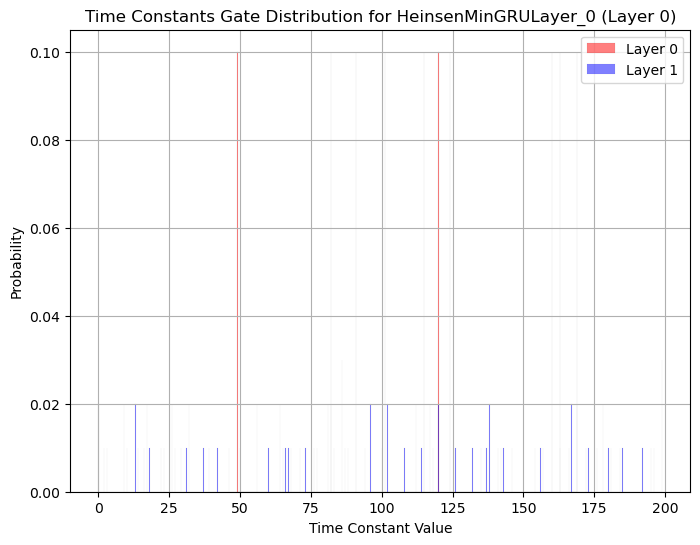

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(model.get_delay_kernel(layer_index=0, args=args).flatten(), fill=True, alpha=0.5, binwidth=0.1, stat="probability", color="red", label="Layer 0")
sns.histplot(model.get_delay_kernel(layer_index=1, args=args).flatten(), fill=True, alpha=0.5, binwidth=0.1, stat="probability", color="blue", label="Layer 1")

# sns.histplot(params_init["params"]['HeinsenMinGRULayer_0'].get('Time_constants_gate', None).flatten(), fill=True, alpha=0.5, binwidth=0.1, stat="probability", color="red", label="Initial")
# sns.histplot(final_state.params['HeinsenMinGRULayer_0'].get('Time_constants_gate', None).flatten(), fill=True, alpha=0.5, binwidth=0.1, stat="probability", color="blue", label="Final")
plt.title(f"Time Constants Gate Distribution for {'HeinsenMinGRULayer_0'} (Layer {0})")
plt.xlabel("Time Constant Value")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()

/home/christian/DenGRU/main/utils.py:477: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


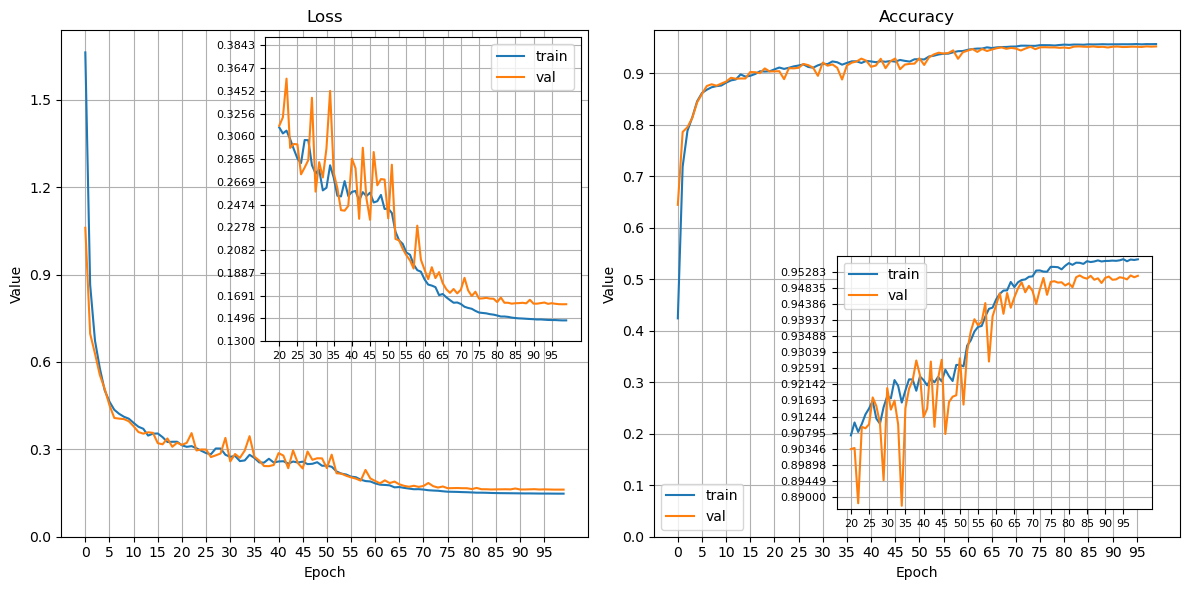

In [15]:
import utils
from importlib import reload
reload(utils)
utils.plot_loss_and_acc(train_losses, val_losses, train_accuracies, val_accuracies, offset=20)

In [15]:
from utils import plot_digits
plot_digits(0, model, final_state.params, 'mingru_heinsen', 
            batch_x, batch_y, PLT_DIR, variable_to_plot='z',
            layer_to_plot=1, nb_components_to_plot=10)

IndexError: list index out of range

(10, 784, 10)


/home/christian/LearningJAX/Flax/utils.py:613: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  for i in range(4):


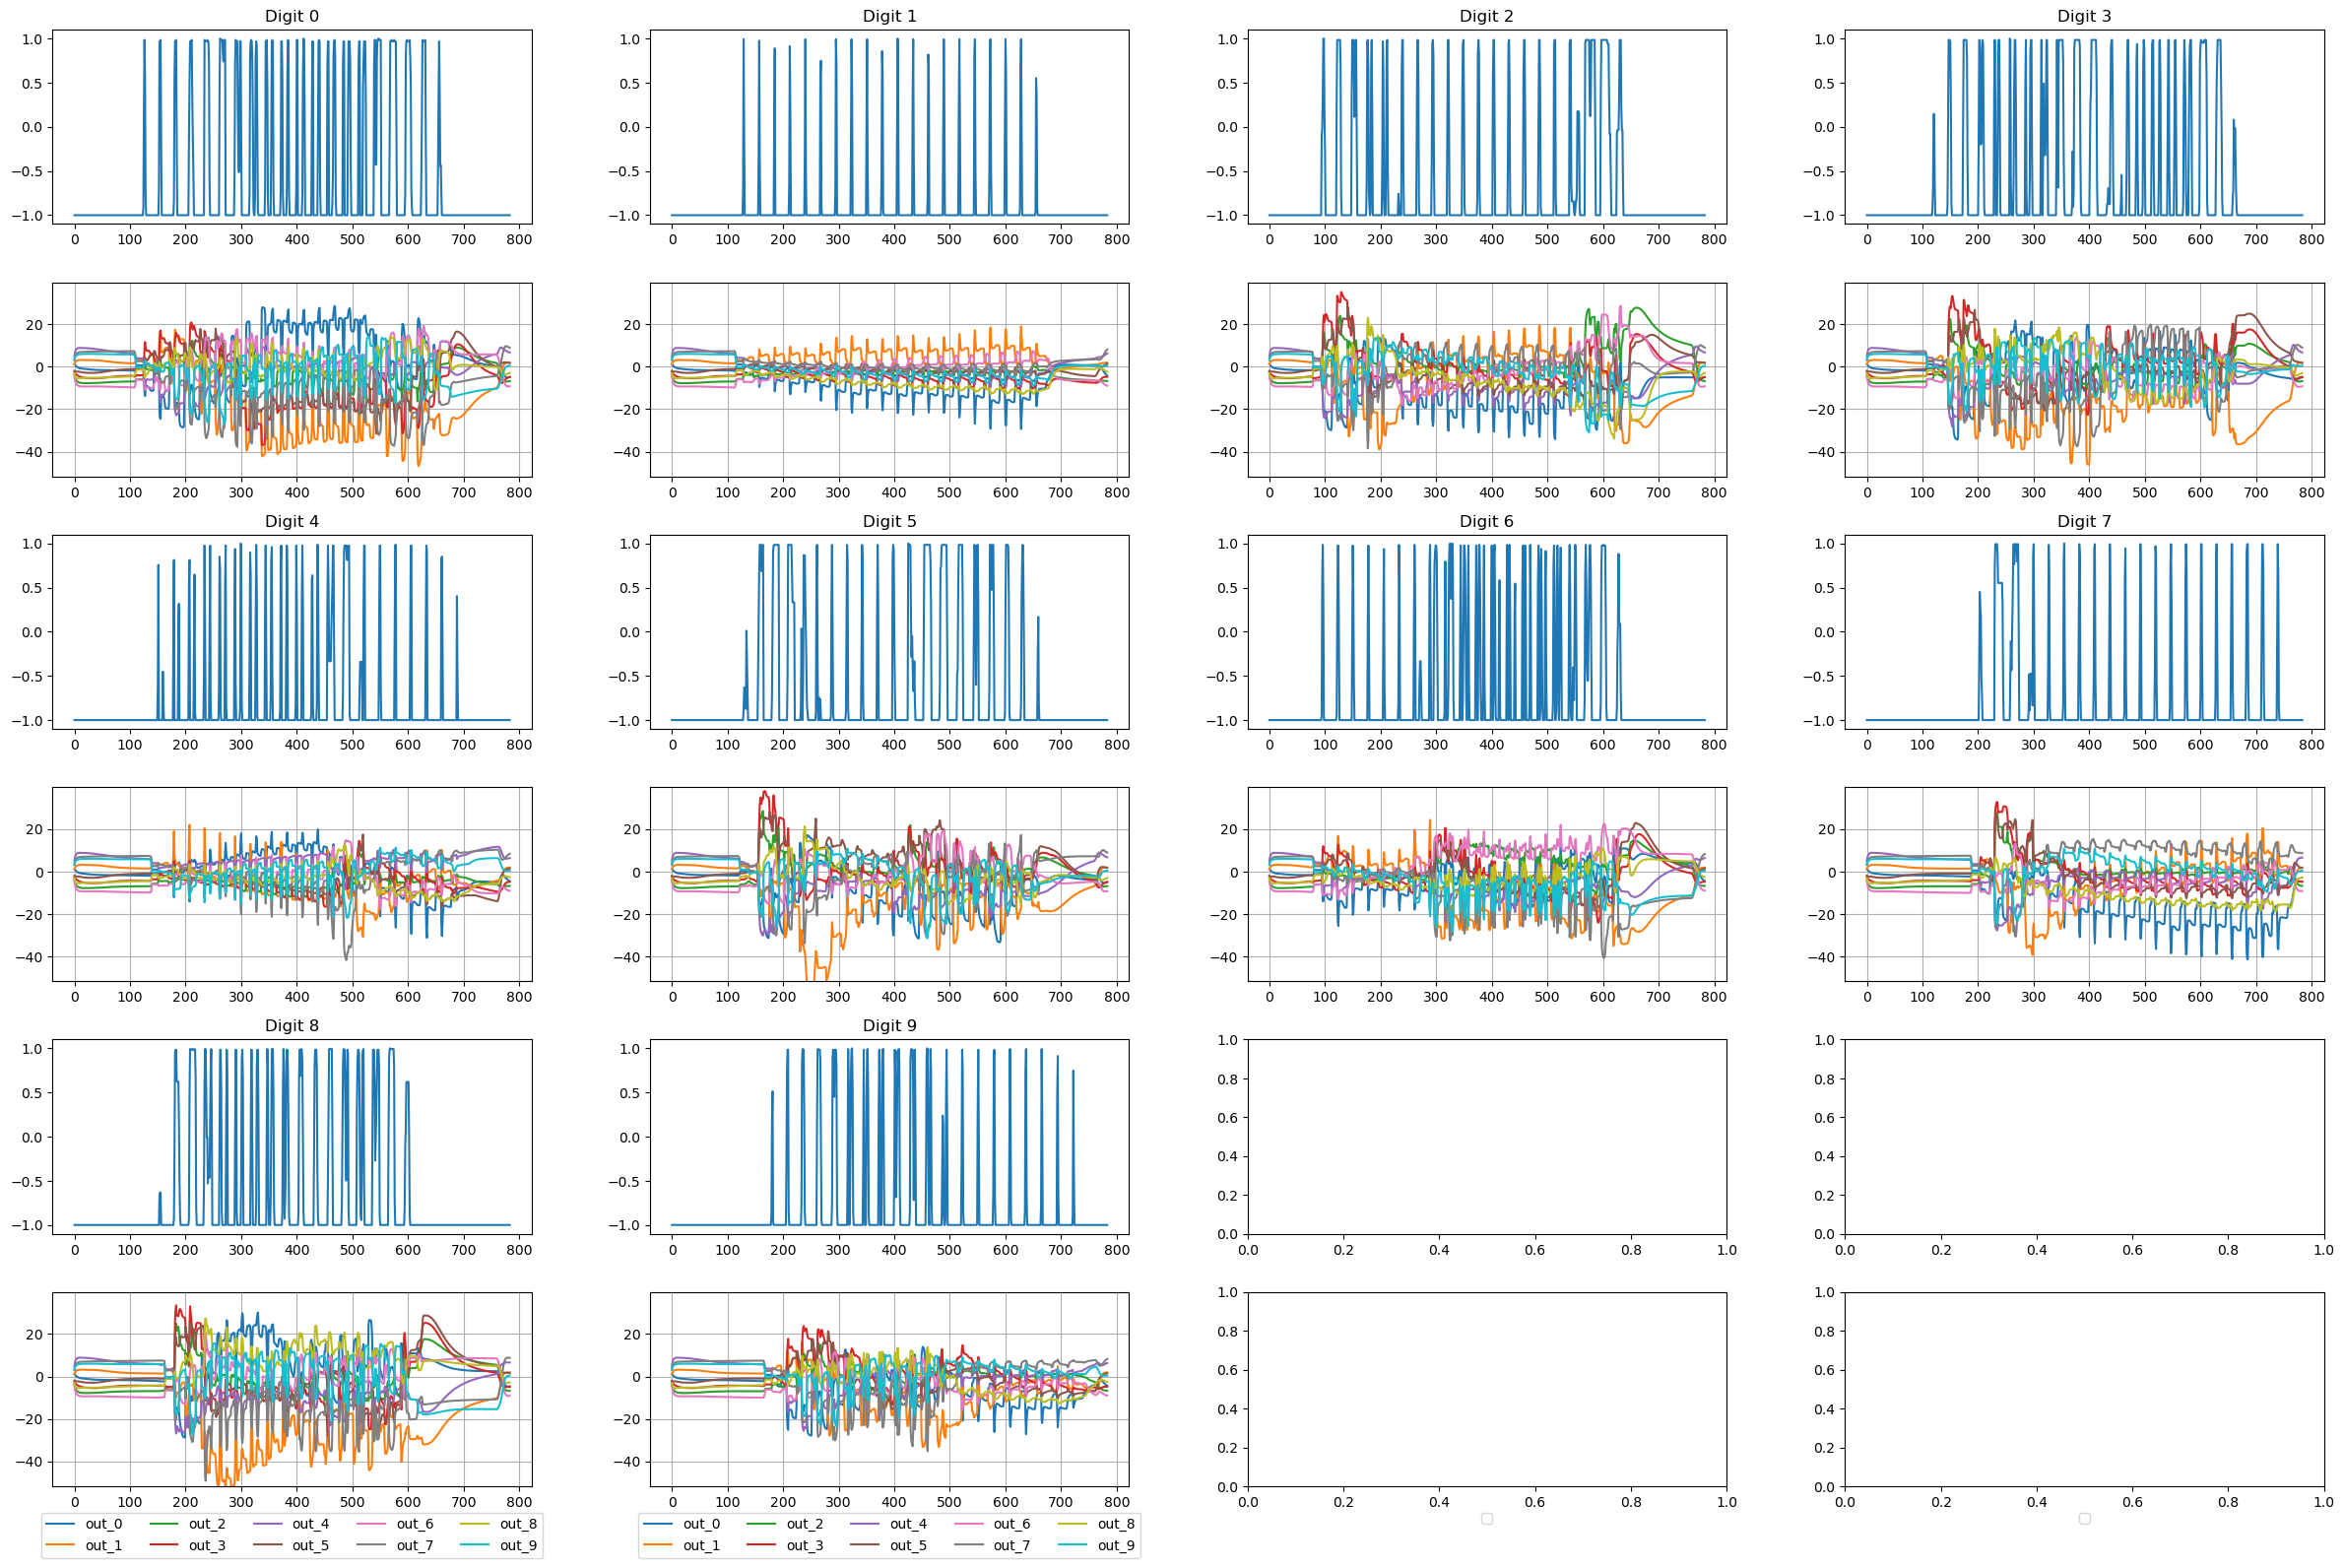

In [121]:
from utils import plot_all_digits
plot_all_digits(model, final_state.params, 'mingru_heinsen', batch_x, batch_y, plt_dir=PLT_DIR, 
                nb_components_to_plot=10, layer_to_plot=1, variable_to_plot='o')


In [37]:
plot_dynamics(model, final_state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=1, model_type='mingru_heinsen', variable_to_plot='all', nb_components_to_plot=3, zoom=False)

/tmp/ipykernel_214348/2150952726.py:78: SyntaxWarning: invalid escape sequence '\s'
  '''


ScopeParamNotFoundError: Could not find parameter named "kernel" in scope "/vmap()/HeinsenMinGRULayer_0/Dense_xh". (https://flax.readthedocs.io/en/latest/api_reference/flax.errors.html#flax.errors.ScopeParamNotFoundError)

2
3
(5, 784, 20)


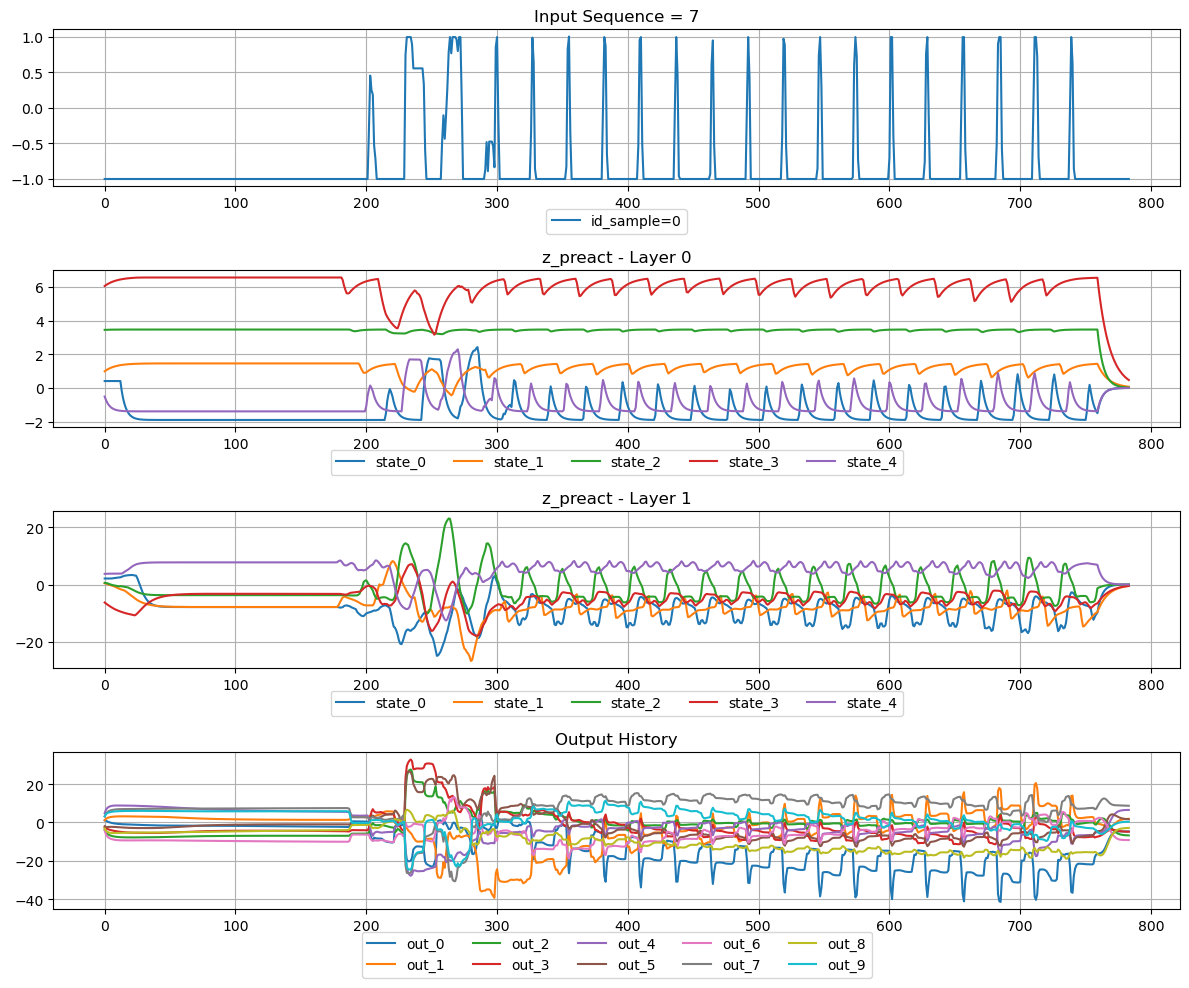

In [123]:
plot_dynamics(model, final_state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=0, model_type='mingru_heinsen', variable_to_plot='z_preact')

2
3
(5, 784, 20)


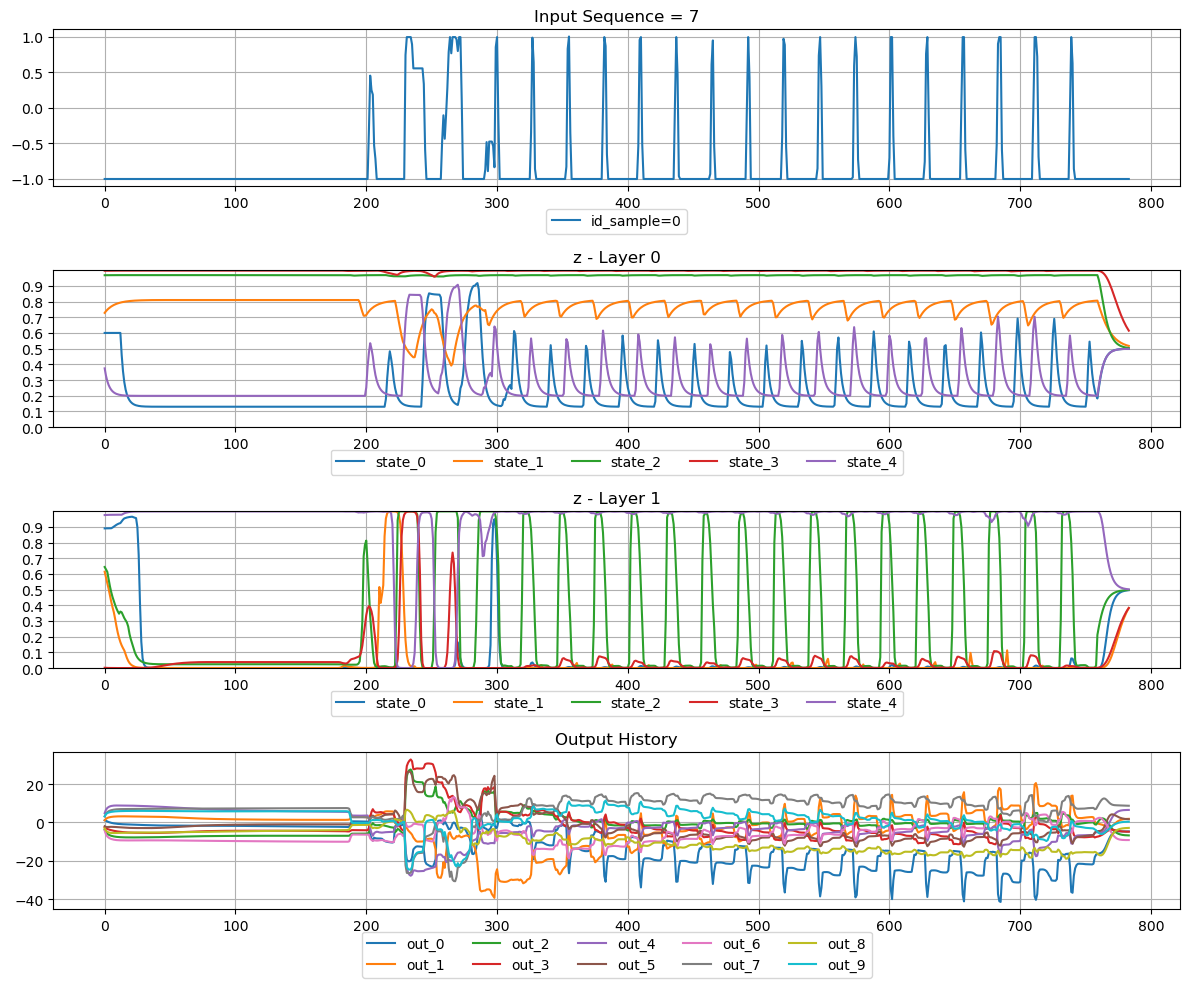

In [124]:
plot_dynamics(model, final_state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=0, model_type='mingru_heinsen', variable_to_plot='z')

2
3
(5, 784, 20)


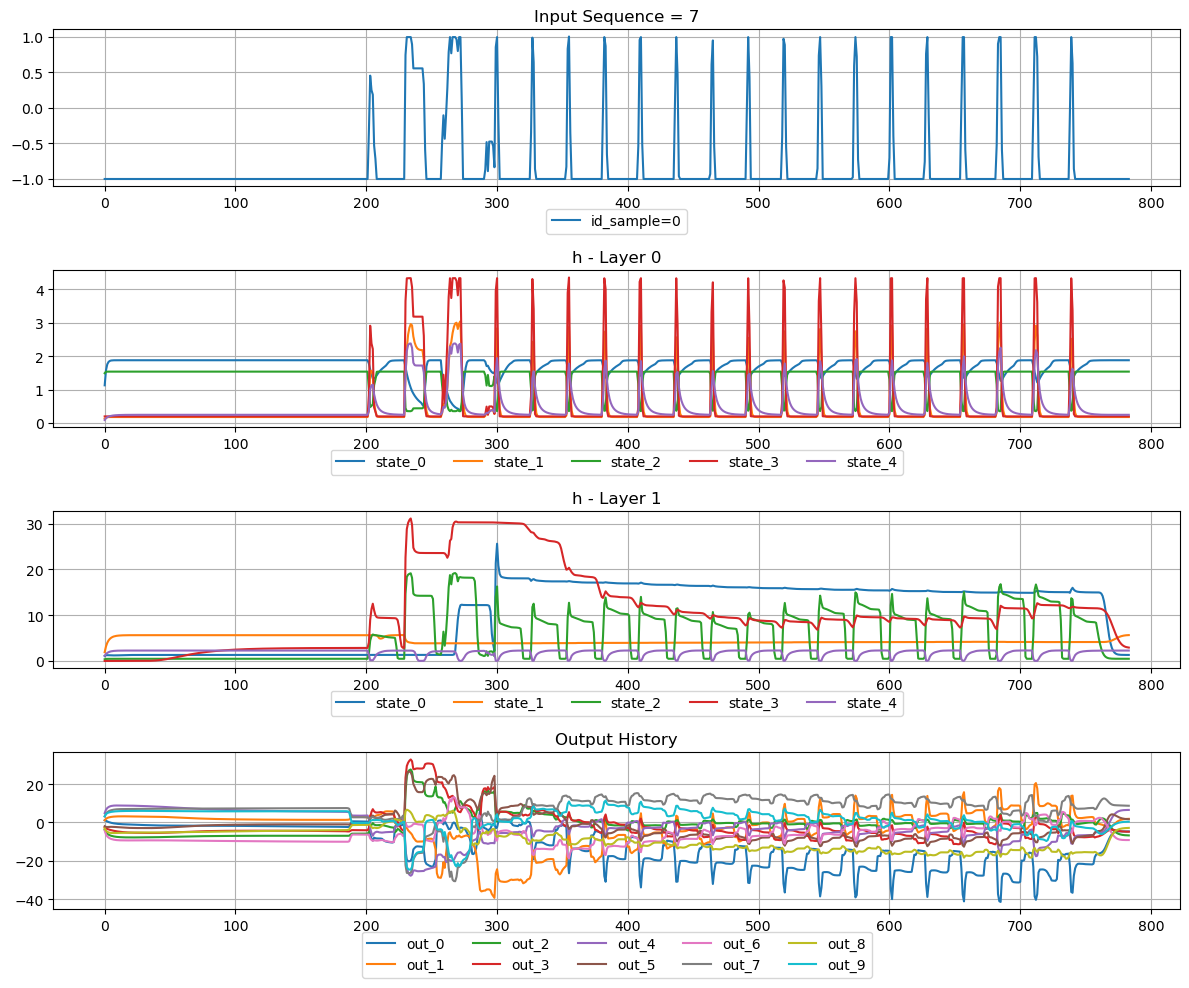

In [125]:
plot_dynamics(model, final_state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=0, model_type='mingru_heinsen', variable_to_plot='h')


2
3
(5, 784, 20)


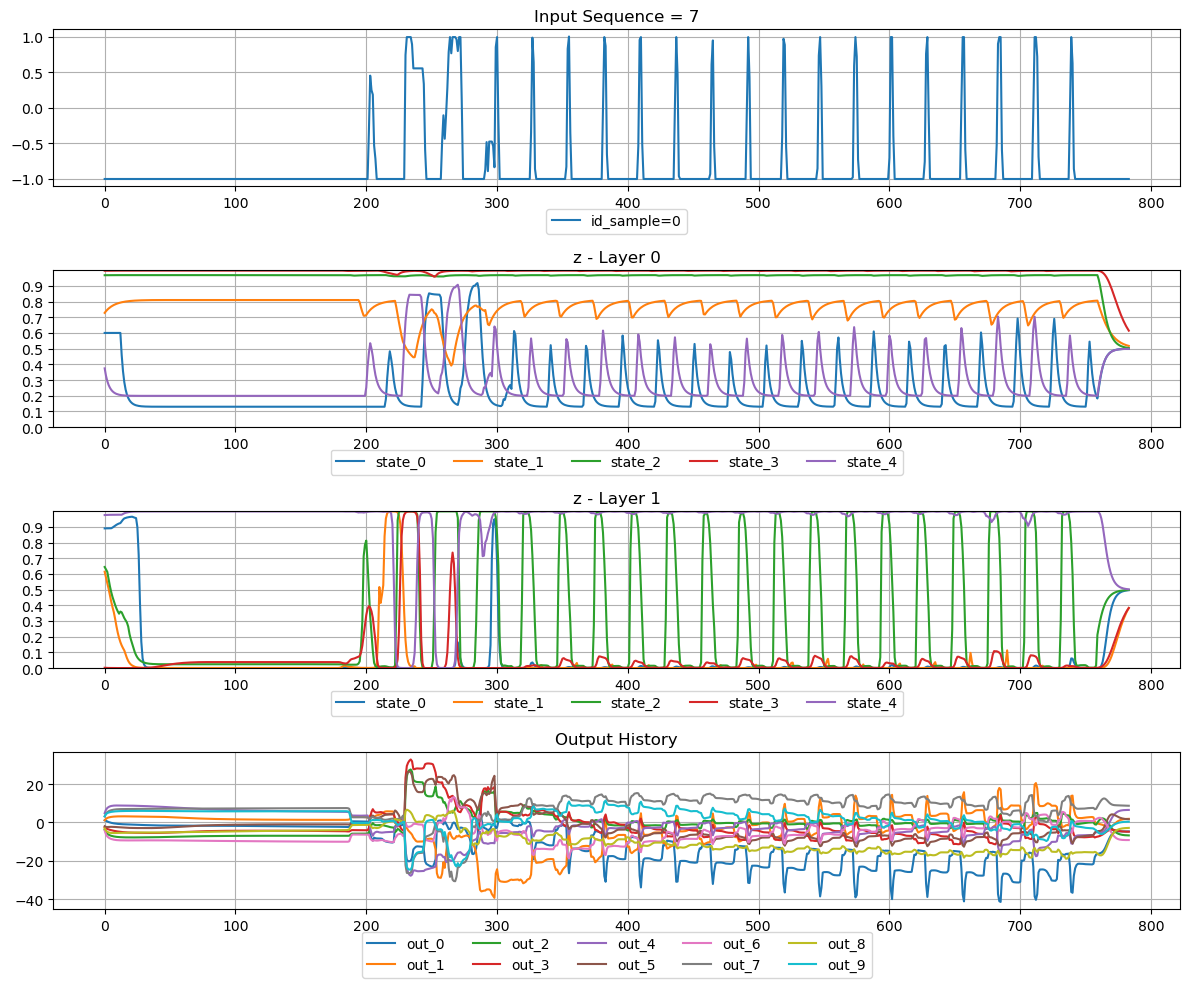

2
3
(5, 784, 20)


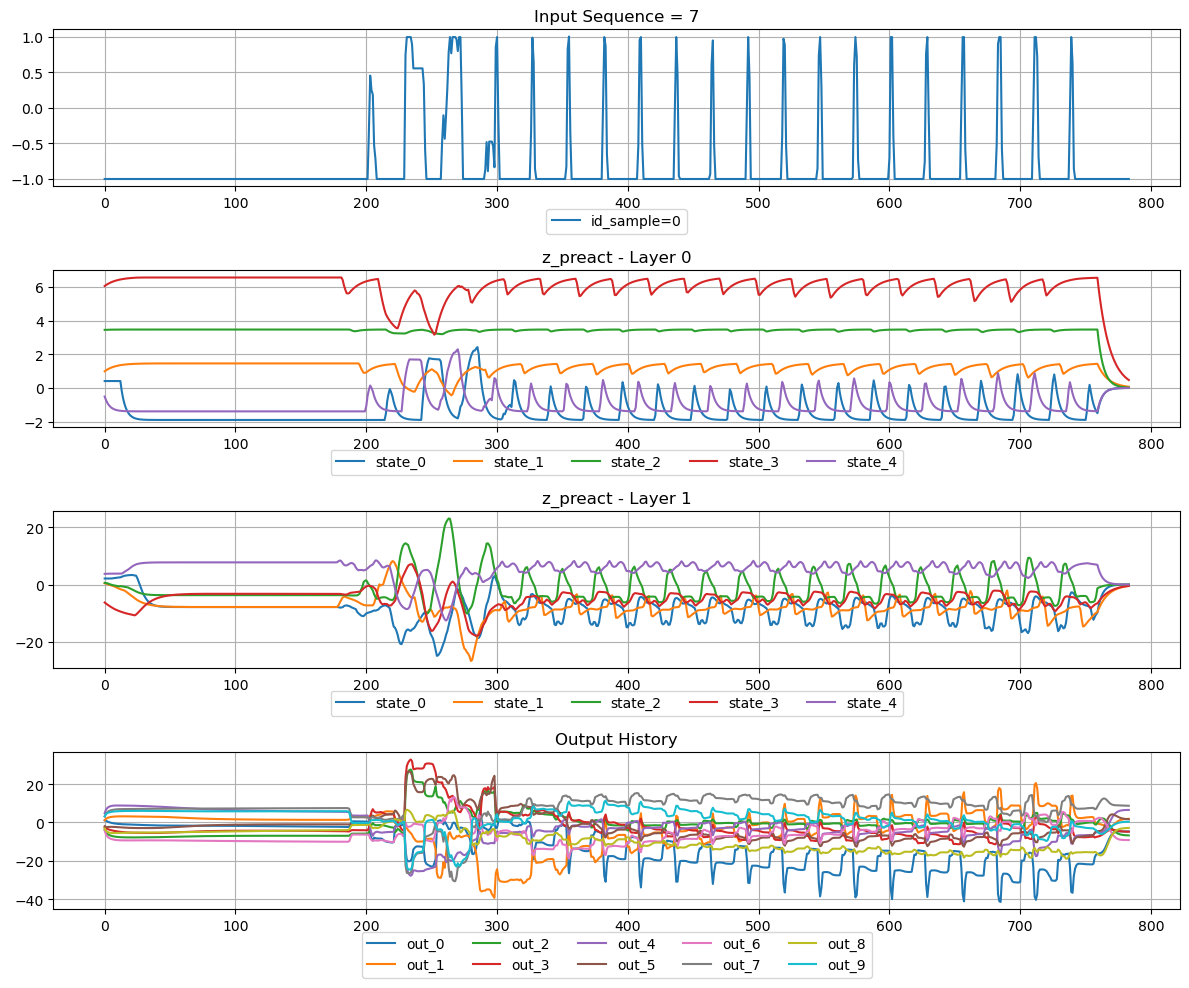

In [126]:
plot_dynamics(model, final_state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=0, model_type='mingru_heinsen', variable_to_plot='z')
plot_dynamics(model, final_state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=0, model_type='mingru_heinsen', variable_to_plot='z_preact')

In [22]:
def plot_distributions(var, name, compartment_labels=None, per_compartment=False, per_layer=False, layer_id=None):
    """
    Plot the distribution of z_preact and h_preact values per compartment.

    Args:
        z_preact: Array of z_preact values (e.g., shape [n_samples, n_compartments]).
        h_preact: Array of h_preact values (e.g., shape [n_samples, n_compartments]).
        compartment_labels: List of labels for compartments (optional).
    """
    n_compartments = var.shape[1]
    if compartment_labels is None:
        compartment_labels = [f"compartment {i}" for i in range(n_compartments)]

    # Plot z_preact distributions
    # plt.figure(figsize=(15, 5))
    if per_compartment:
        for i in range(n_compartments):
            sns.histplot(var[:, i], label=compartment_labels[i], fill=True, alpha=0.5, binwidth=0.02, stat="probability")#, bins=30)
            plt.title(f"Distribution of {name} values per compartment")

    else:
        sns.histplot(var.flatten(), label=f"layer {layer_id}", fill=True, alpha=0.5, binwidth=0.02, stat="probability")#,binrange = (-2.5,+2.5))
        plt.title(f"Distribution of {name} values per layer")

    plt.xlabel(name)
    plt.ylabel("probability")
    plt.legend()

In [23]:
params=final_state.params
if 'params' not in final_state.params:
    params = {'params': params}

state_hist, out_hist = model.apply(params, batch_x[:3])
components = 50




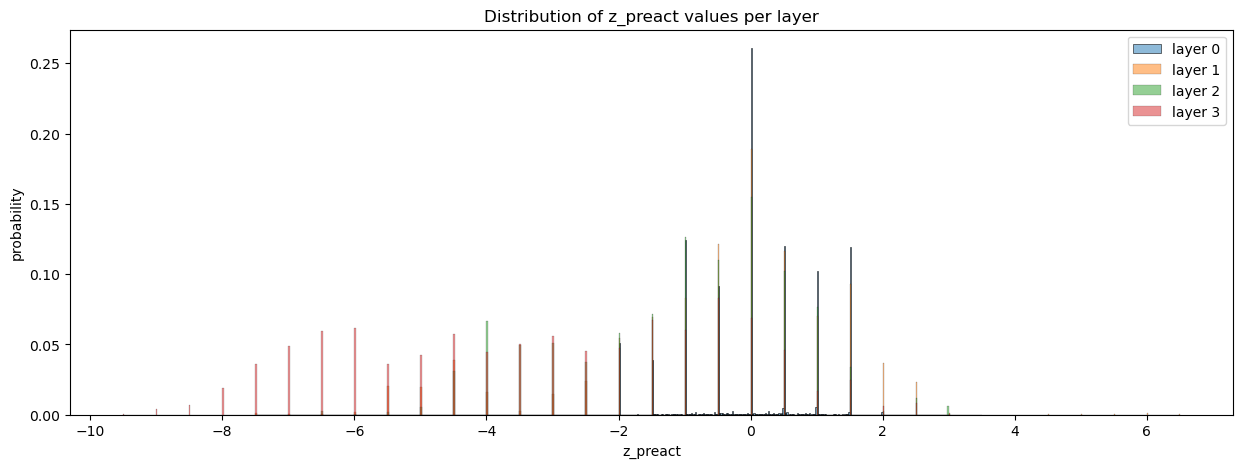

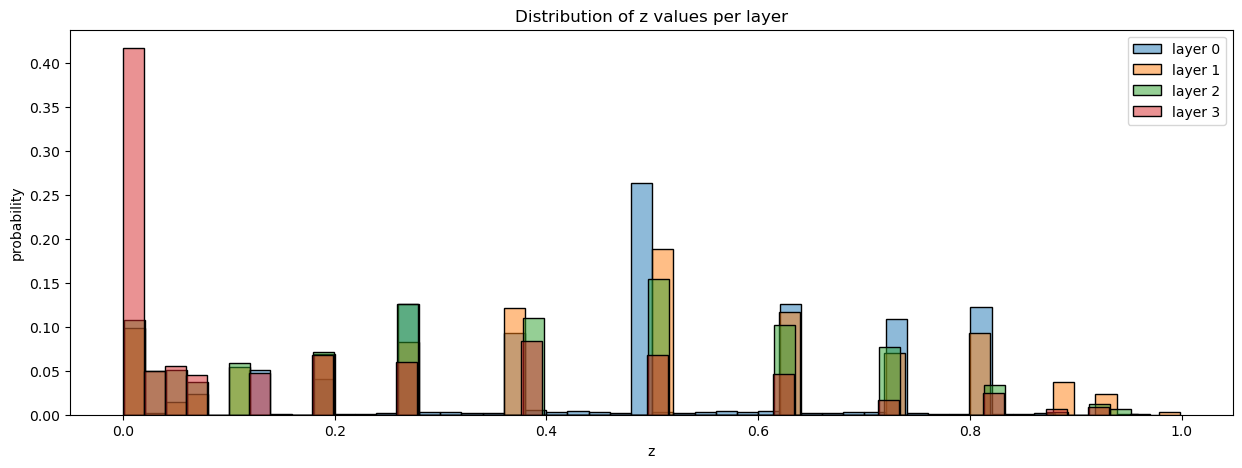

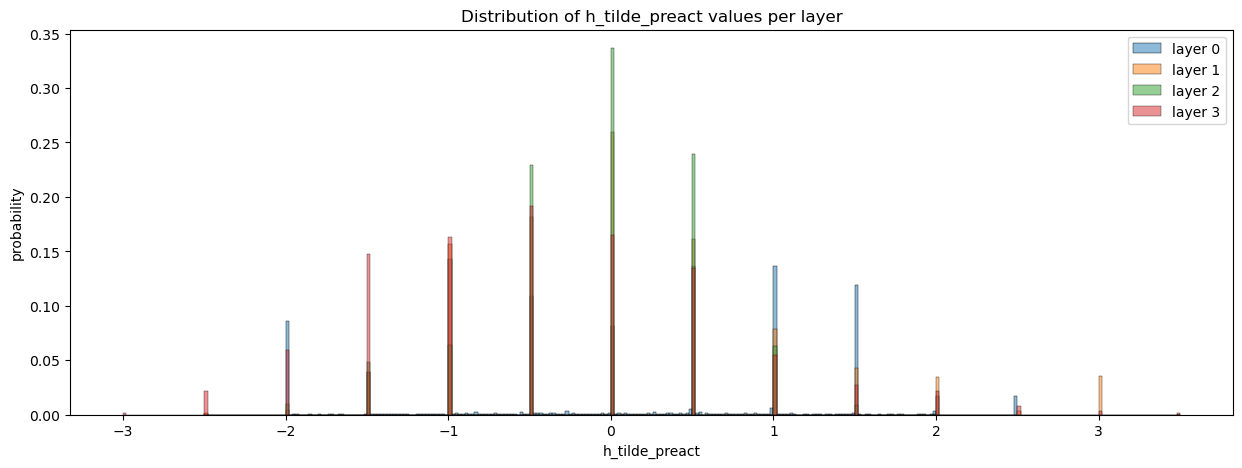

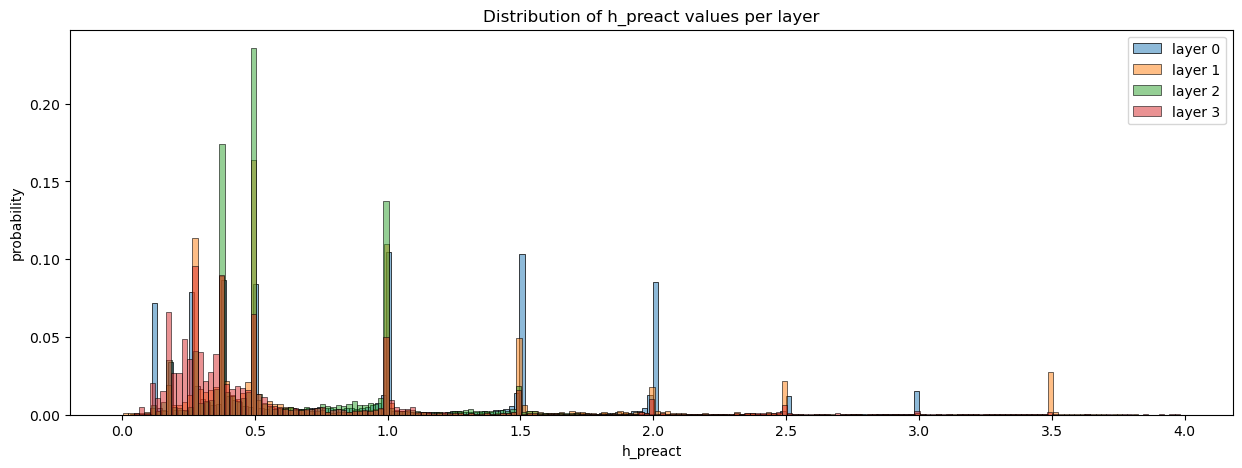

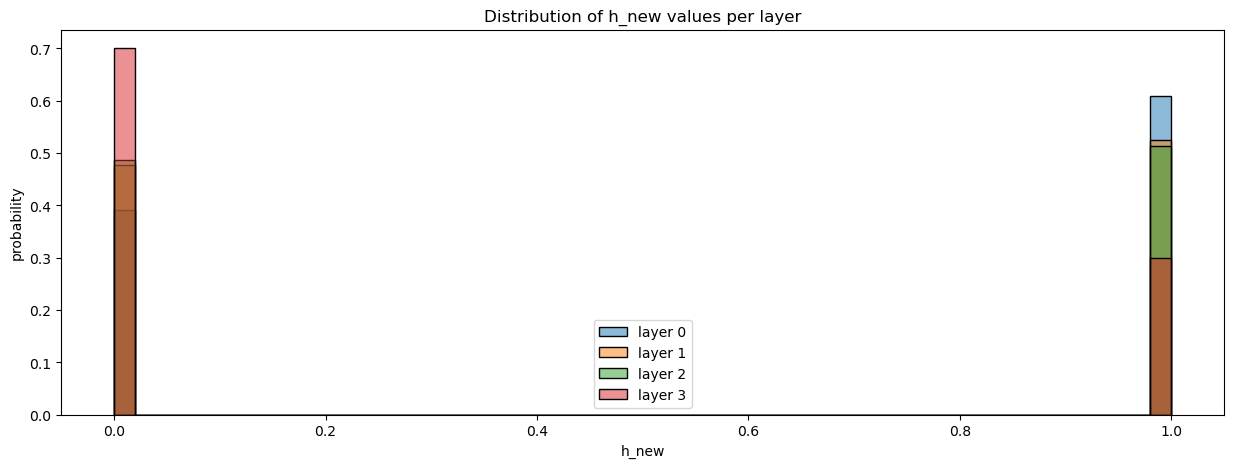

In [24]:
plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][1][0, :, :components], "z_preact", compartment_labels=None, layer_id=i)

plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(jax.nn.sigmoid(state_hist[i][1][0, :, :components]), "z", compartment_labels=None, layer_id=i)


plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][2][0, :, :components], "h_tilde_preact", compartment_labels=None, layer_id=i)


plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][3][0, :, :components], "h_preact", compartment_labels=None, layer_id=i)

plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][0][0, :, :components], "h_new", compartment_labels=None, layer_id=i)


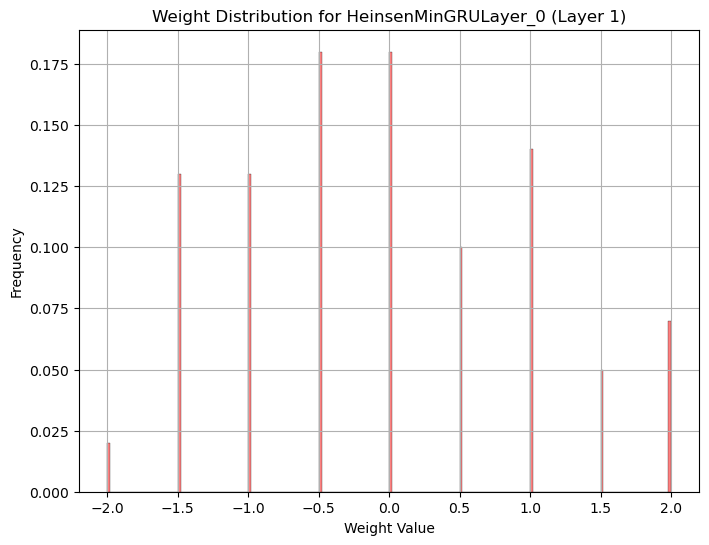

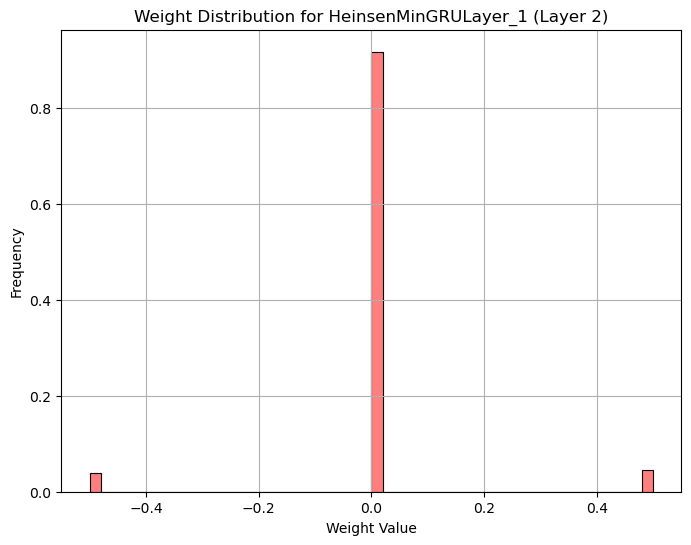

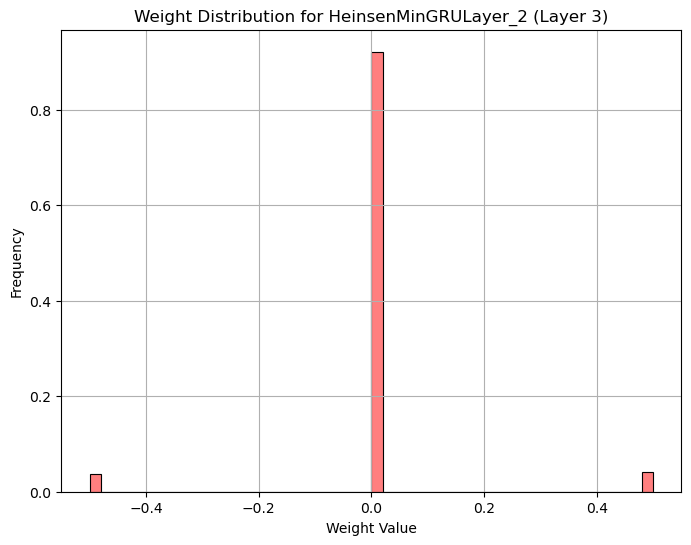

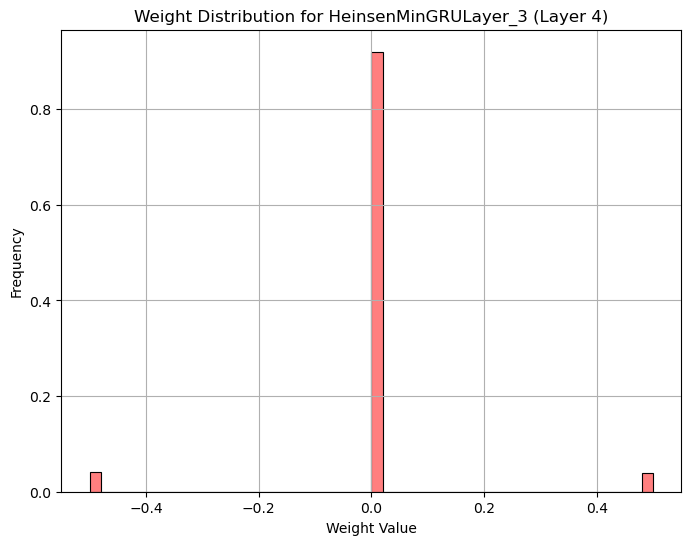

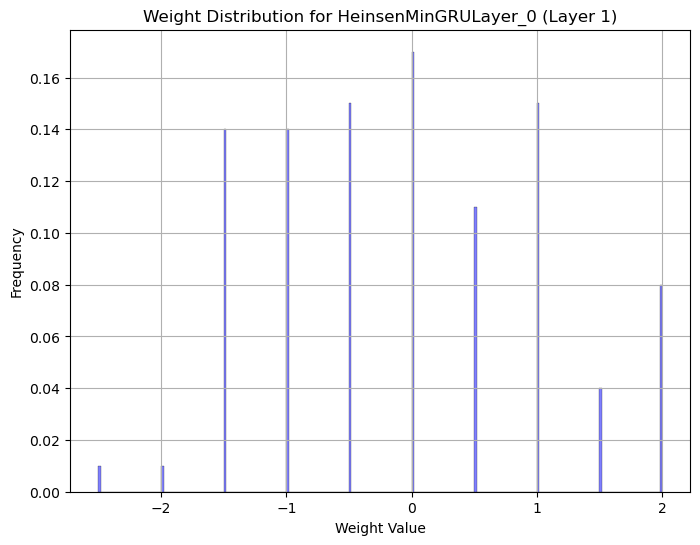

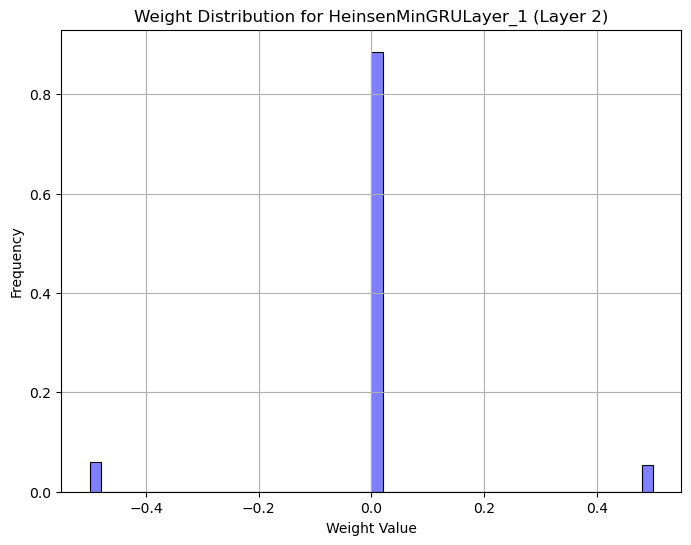

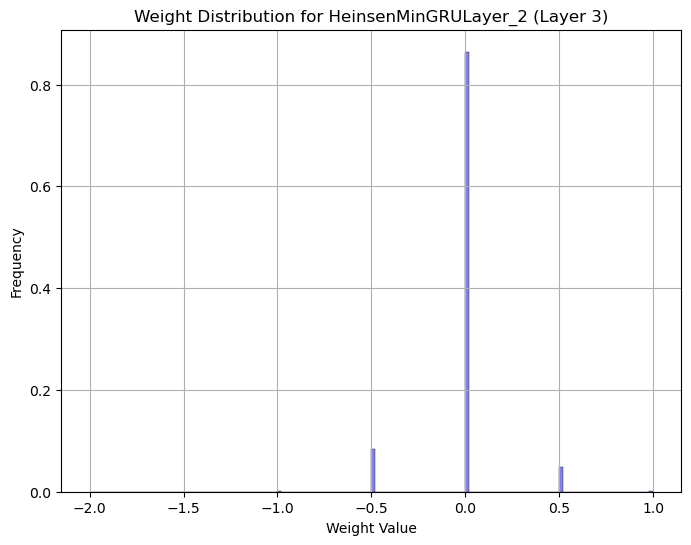

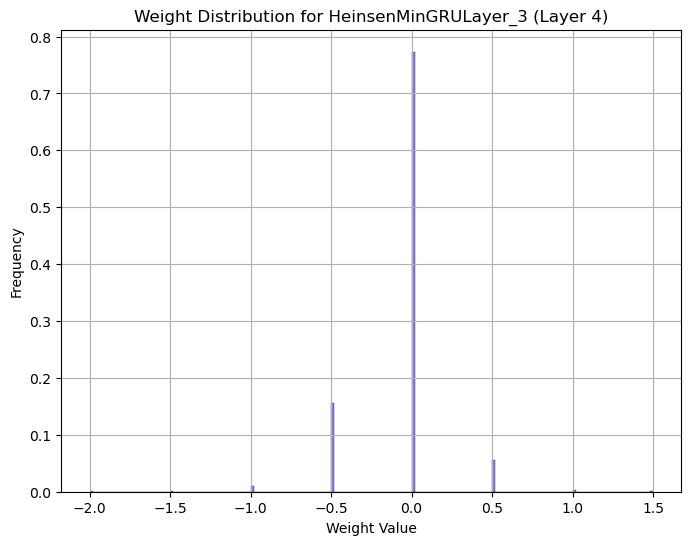

In [25]:
def plot_layer_weights_histogram(params, layer_prefix="HeinsenMinGRULayer", color=None):
    """
    Plot histograms of weights for each layer in the model.

    Args:
        params: Model parameters (e.g., from `final_state.params`).
        layer_prefix: Prefix for layer names in the parameter dictionary.
    """
    for layer_id, layer_name in enumerate(params.keys()):
        if layer_prefix in layer_name:
            # Extract weights for the layer
            layer_weights = params[layer_name]['Dense_x']['kernel']  # Adjust key names if needed
            layer_weights = np.array(layer_weights)  # Convert to NumPy array if necessary

            # Plot histogram
            plt.figure(figsize=(8, 6))
            sns.histplot(layer_weights.flatten(), fill=True, alpha=0.5, binwidth=0.02, stat="probability", color=color)
            plt.title(f"Weight Distribution for {layer_name} (Layer {layer_id})")
            plt.xlabel("Weight Value")
            plt.ylabel("Frequency")
            plt.grid(True)
            plt.show()

plot_layer_weights_histogram(round_weights_to_nearest(params_init["params"]), color="red")
plot_layer_weights_histogram(final_state.params, color="blue")

In [26]:
def plot_weight_time_constant_correlation(params, layer_id, color=None):
    """
    Plot the correlation between weight magnitude into a specific unit of a specific layer
    and the associated time constants.

    Args:
        params: Model parameters (e.g., from `final_state.params`).
        layer_id: The layer index to analyze.
        unit_id: The unit index within the layer to analyze.
        time_constants: Array of time constants for the specific layer.
    """
    # Extract weights for the specific layer
    layer_weights = params[f"HeinsenMinGRULayer_{layer_id}"]['Dense_x']['kernel'][:,:50]  # Adjust key names as needed
    # layer_bias = params['params'][f"HeinsenMinGRULayer_{layer_id}"]['Dense_x']['bias']  # Adjust key names as needed
    print(np.shape(layer_weights))
    weight_magnitudes = np.linalg.norm(layer_weights, axis=0)  # Compute L2 norms of weights into each unit
    print("Weight magnitudes:", np.shape(weight_magnitudes))

    key = jax.random.PRNGKey(args.seed)
    key_list = [key]*args.n_layers
    key_list = jax.random.split(key,args.n_layers)
    time_constants = jax.random.uniform(key_list[layer_id], (args.hidden_dim,), minval=args.time_decay_mean[1], maxval=args.time_decay_mean[0])

    # Plot correlation
    sns.jointplot(
        x=weight_magnitudes,
        y=time_constants,
        kind="scatter",
        marginal_kws=dict(bins=100, fill=True),
        color=color
    ).set_axis_labels("Weight Magnitude", "Time Constant")

    plt.suptitle(f"Weight Magnitudes and Time Constants (Layer {layer_id})", y=1.02)
    plt.show()

# look only at first 50

(1, 50)
Weight magnitudes: (50,)


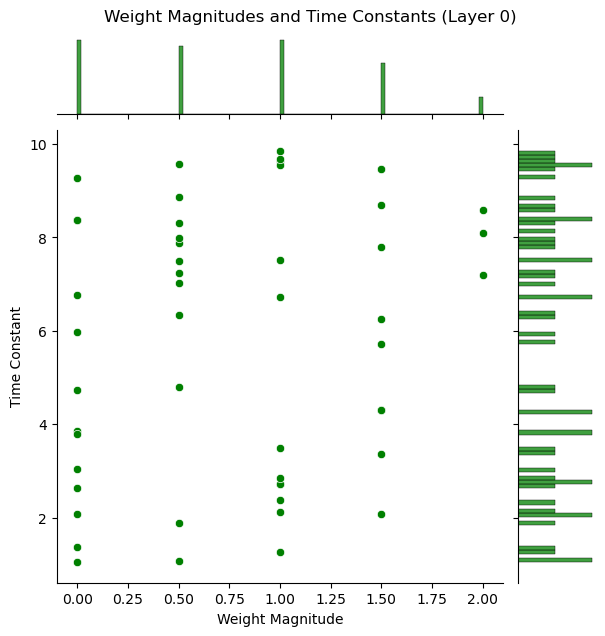

(50, 50)
Weight magnitudes: (50,)


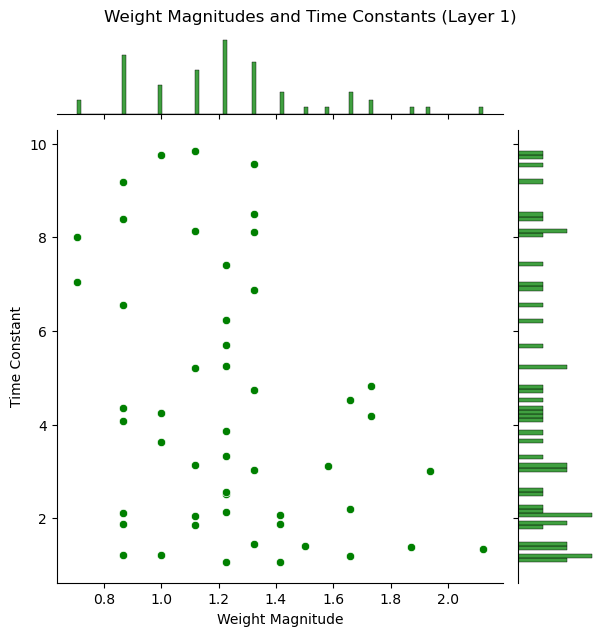

(50, 50)
Weight magnitudes: (50,)


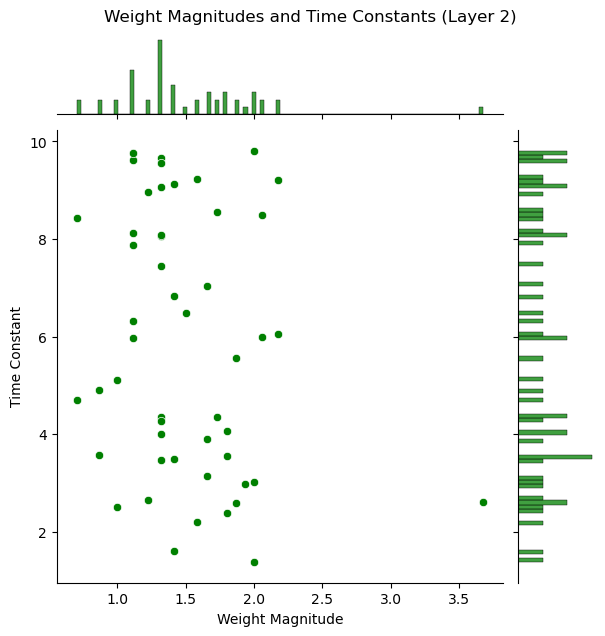

(50, 50)
Weight magnitudes: (50,)


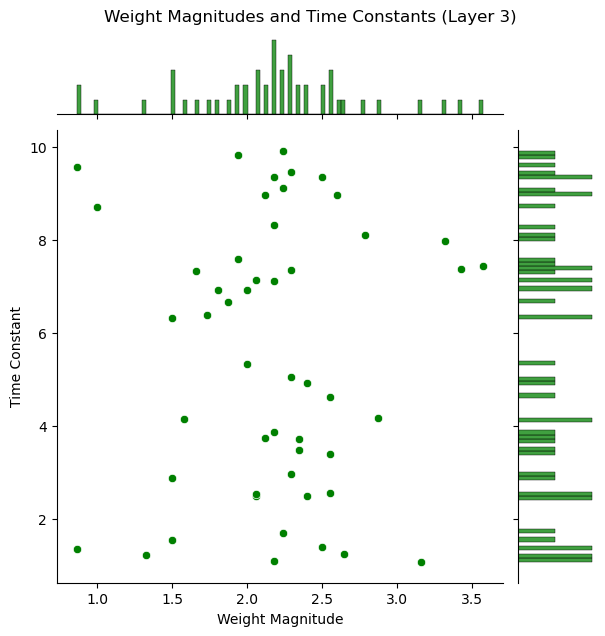

(1, 50)
Weight magnitudes: (50,)


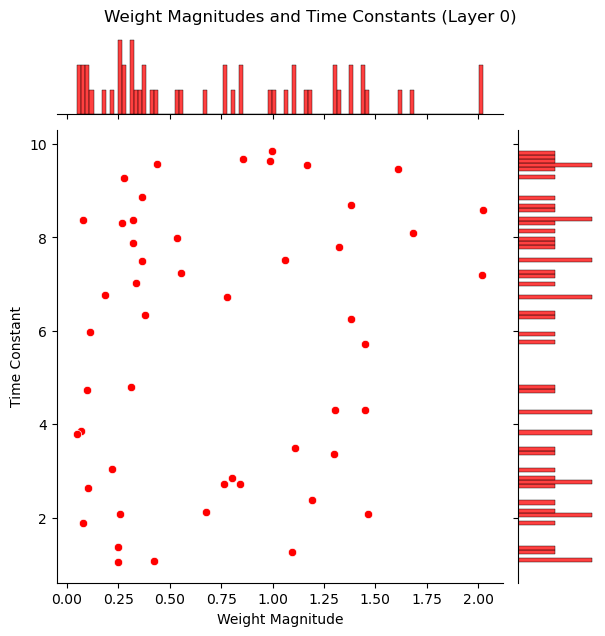

(50, 50)
Weight magnitudes: (50,)


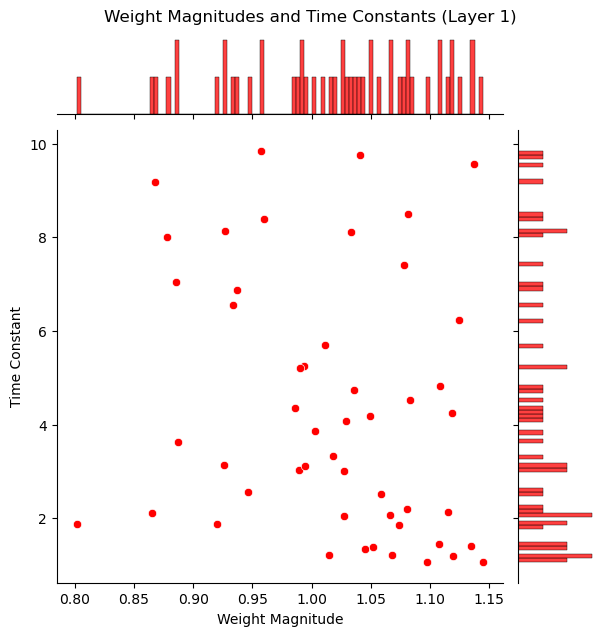

(50, 50)
Weight magnitudes: (50,)


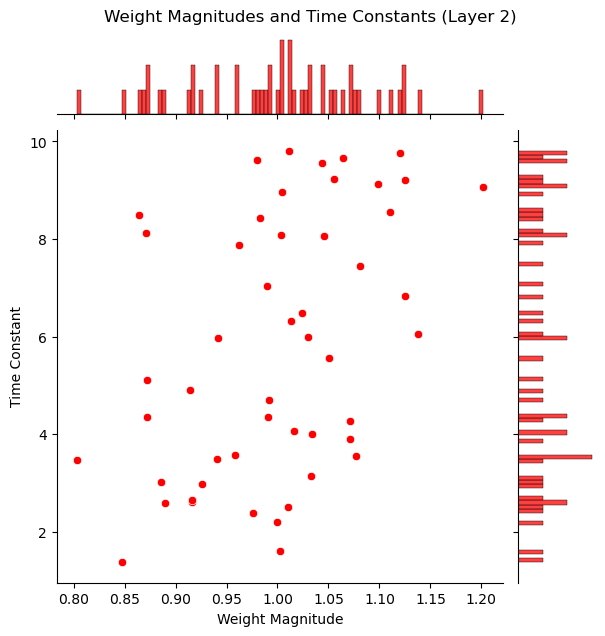

(50, 50)
Weight magnitudes: (50,)


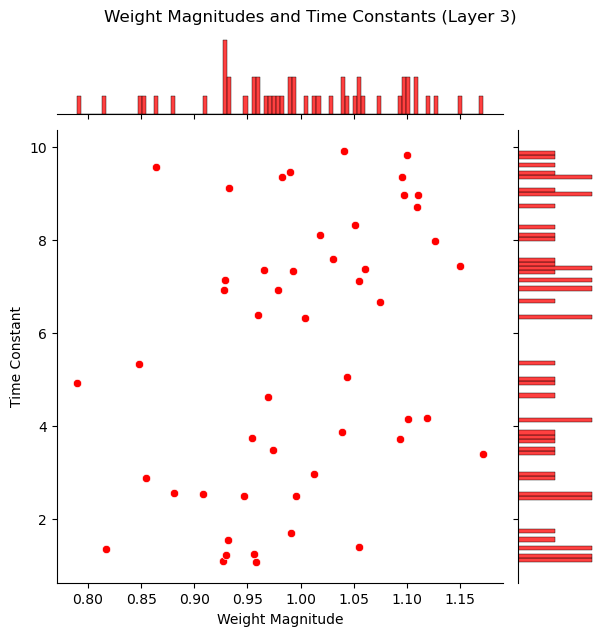

In [27]:
layer_id = 2  # Specify the layer index
# print(final_state.params)
for i in range(args.n_layers):
    plot_weight_time_constant_correlation(final_state.params, i, color="green")



for i in range(args.n_layers):
    plot_weight_time_constant_correlation(params_init["params"], i, color="red")

In [28]:
final_state = checkpoints.restore_checkpoint("LearningJAX/Flax/checkpoints/mingru_heinsen/mnist/sequential_h50_l4_dyn_alllayer_dyn_lr0.001_act_threshold10.0testing", target=final_state)

params=final_state.params
if 'params' not in final_state.params:
    params = {'params': params}

state_hist, out_hist = model.apply(params, batch_x[:3])
components = 50
layer_id = 1



h_new = state_hist[layer_id][0][0, :, :components]
z_preact = state_hist[layer_id][1][0, :, :components]
h_tilde_preact = state_hist[layer_id][2][0, :, :components]
h_preact = state_hist[layer_id][3][0, :, :components]



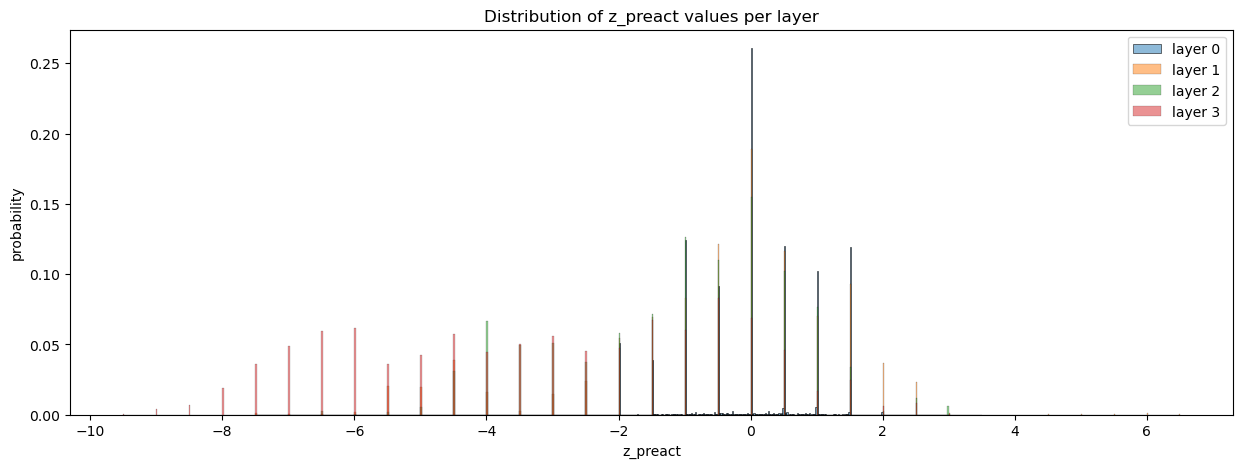

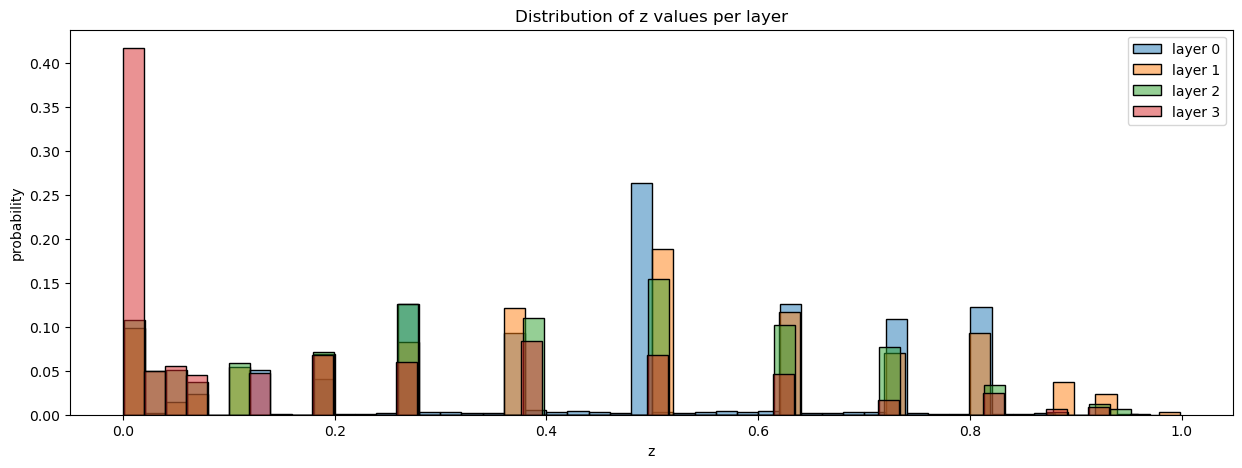

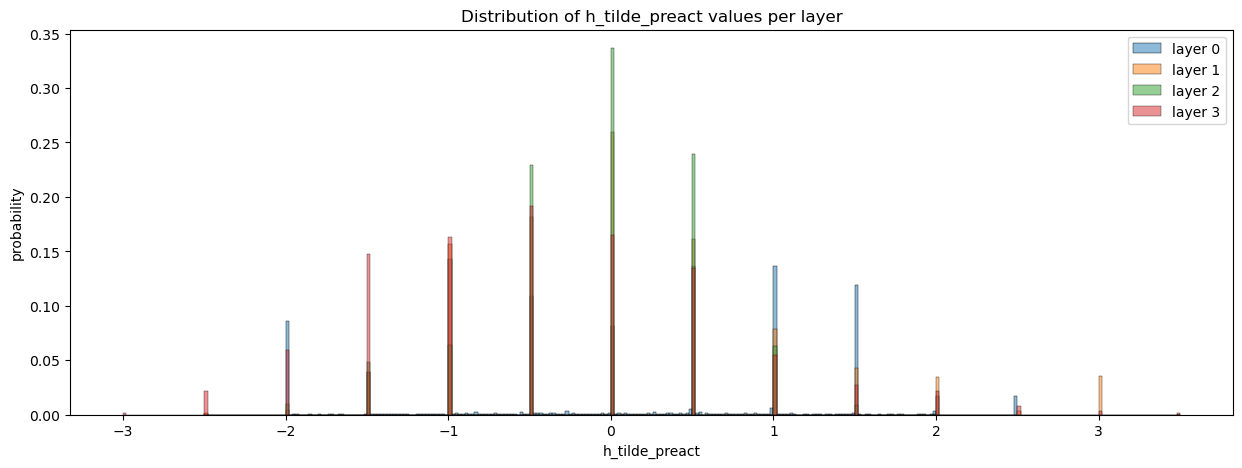

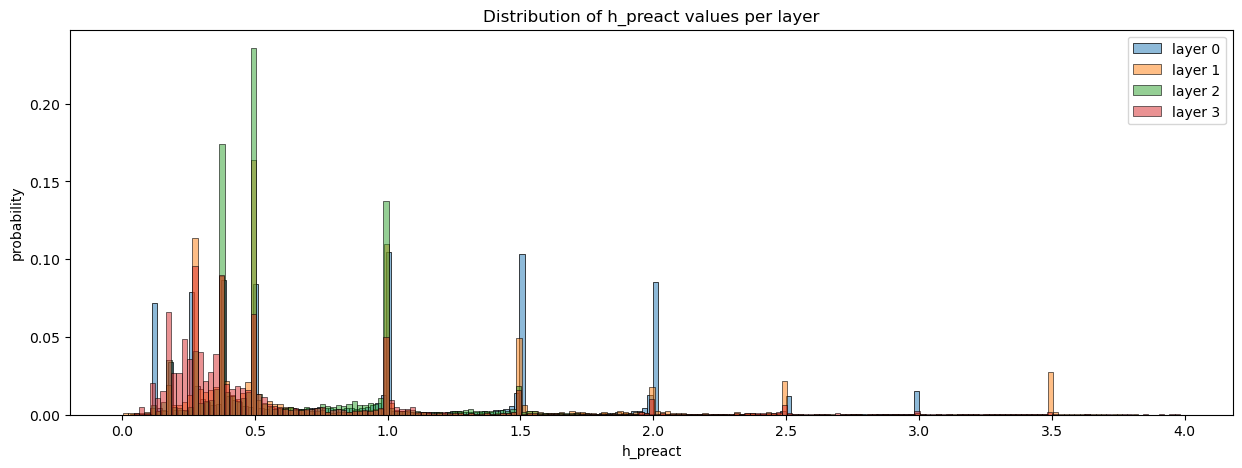

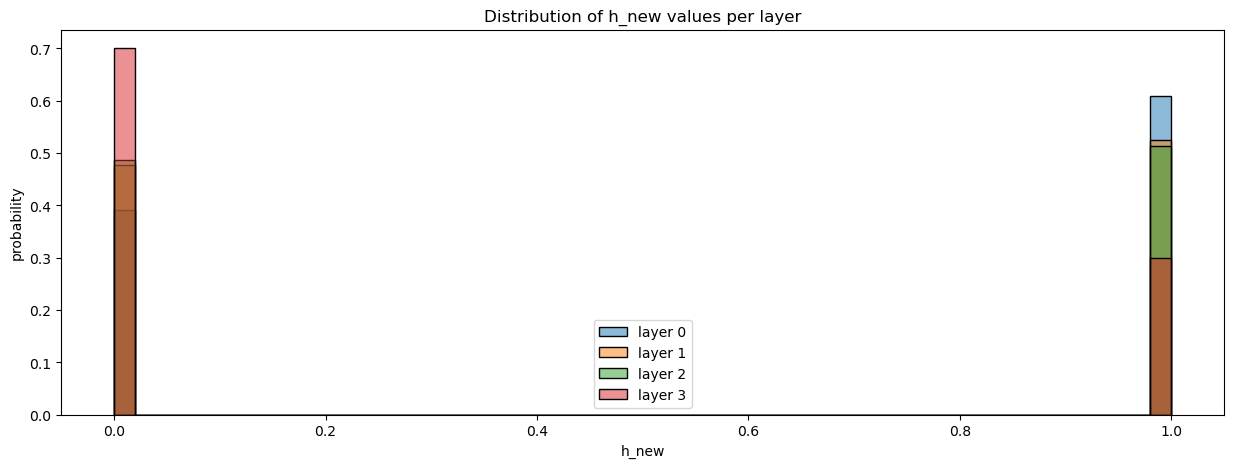

In [29]:
plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][1][0, :, :components], "z_preact", compartment_labels=None, layer_id=i)

plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(jax.nn.sigmoid(state_hist[i][1][0, :, :components]), "z", compartment_labels=None, layer_id=i)


plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][2][0, :, :components], "h_tilde_preact", compartment_labels=None, layer_id=i)


plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][3][0, :, :components], "h_preact", compartment_labels=None, layer_id=i)

plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][0][0, :, :components], "h_new", compartment_labels=None, layer_id=i)
